### Importar librerías

In [61]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import os
from collections import Counter
from scipy.fft import fft, fftfreq
import scipy.signal as signal
from scipy.signal import welch, butter, filtfilt
from scipy.integrate import trapezoid
import seaborn as sns
import pandas as pd
import ast
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Cargar datos y patologías

In [62]:
# Definimos la ruta relativa al dataset original (MODIFICAR SEGÚN TU ESTRUCTURA DE CARPETAS)
PATH_DATA = Path('../data/raw/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3') 

# Verificamos si la ruta existe para que sea fácil identificar si alguien olvidó descargar los datos
if not PATH_DATA.exists():
    print(f"Error: No se encontró la carpeta de datos en {PATH_DATA.resolve()}")
    print("Asegúrate de haber descargado el dataset y haberlo colocado en 'data/raw'.")
else:
    # Leemos el archivo
    df_meta = pd.read_csv(os.path.join(PATH_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
    
    # Convertimos los códigos SCP de strings a diccionarios de Python
    df_meta['scp_codes'] = df_meta['scp_codes'].apply(lambda x: ast.literal_eval(x))
    print("¡Dataset cargado exitosamente!")

¡Dataset cargado exitosamente!


In [63]:
# 3. Función auxiliar para extraer la patología principal
def obtener_patologia_principal(diccionario_codigos):
    if not diccionario_codigos:
        return 'UNKNOWN'
    # Retorna la clave con el valor estadístico más alto en el reporte médico
    return max(diccionario_codigos, key=diccionario_codigos.get)

# Aplicar la función sobre el df_meta que ya está guardado en memoria
df_meta['patologia_principal'] = df_meta['scp_codes'].apply(obtener_patologia_principal)

# 4. Filtrar y contar las clases críticas de nuestro universo de estudio
clases_interes = ['NORM', 'IRBBB', 'CRBBB', 'CLBBB', 'ILBBB', 'IMI', 'AMI']
conteo_patologias = df_meta['patologia_principal'].value_counts().reindex(clases_interes).fillna(0).astype(int)

# 5. Presentar los resultados en el DataFrame prolijo para la cátedra
df_analisis_exploratorio = pd.DataFrame({
    'Código SCP': clases_interes,
    'Descripción Clínica': [
        'Registros Normales (Control)',
        'Bloqueo Incompleto de Rama Derecha (BIRD)',
        'Bloqueo Completo de Rama Derecha (BCRD)',
        'Bloqueo Completo de Rama Izquierda (BCRI)',
        'Bloqueo Incompleto de Rama Izquierda (ILBBB)',
        'Infarto de Miocardio Inferior',
        'Infarto de Miocardio Anterior'
    ],
    'Cantidad de Registros en Base Total': conteo_patologias.values
})

print("=====================================================================")
print(" ANALISIS EXPLORATORIO CUANTITATIVO DEL DATASET (PTB-XL)")
print("=====================================================================")
display(df_analisis_exploratorio)

 ANALISIS EXPLORATORIO CUANTITATIVO DEL DATASET (PTB-XL)


,Código SCP,Descripción Clínica,Cantidad de Registros en Base Total
0,NORM,Registros Normales (Control),9134
1,IRBBB,Bloqueo Incompleto de Rama Derecha (BIRD),831
2,CRBBB,Bloqueo Completo de Rama Derecha (BCRD),385
3,CLBBB,Bloqueo Completo de Rama Izquierda (BCRI),527
4,ILBBB,Bloqueo Incompleto de Rama Izquierda (ILBBB),45
5,IMI,Infarto de Miocardio Inferior,1677
6,AMI,Infarto de Miocardio Anterior,173


# Creación de diccionario de pacientes equilibrado

In [64]:
# =============================================================================
# CONSTRUCCIÓN DEL DATASET ROBUSTO Y BALANCEADO (ESCALADO)
# =============================================================================

# Definimos el número objetivo de pacientes por clase (Estadísticamente más representativo)
PACIENTES_POR_CLASE_OBJETIVO = 100  
clases_pipeline = ['NORM', 'IRBBB', 'CRBBB', 'CLBBB', 'ILBBB']

dataset_proyecto = {}
np.random.seed(42)  # Mantiene la repetibilidad de la muestra aleatoria

print("Iniciando indexación robusta del dataset...")

for clase in clases_pipeline:
    # Filtrar en la metadata los IDs que pertenezcan a la patología actual
    ids_disponibles = df_meta[df_meta['patologia_principal'] == clase].index.tolist()
    
    # SEGURO ANTIFALLOS: Si la clase tiene menos del objetivo, toma el máximo disponible
    cantidad_a_extraer = min(PACIENTES_POR_CLASE_OBJETIVO, len(ids_disponibles))
    
    # Elegir los IDs aleatorios de forma segura
    ids_seleccionados = np.random.choice(ids_disponibles, cantidad_a_extraer, replace=False)
    
    print(f"  • Clase {clase:5s}: Indexando {cantidad_a_extraer} pacientes (Disponibles totales: {len(ids_disponibles)})")
    
    for ecg_id in ids_seleccionados:
        clave_paciente = f"paciente_{ecg_id}"
        
        dataset_proyecto[clave_paciente] = {
            'ecg_id': int(ecg_id),
            'clase_clinica': clase,
            # Simplificamos las llaves eliminando la alta resolución por completo
            'file_path': df_meta.loc[ecg_id, 'filename_lr'],
            'fs': 100,  # Frecuencia estandarizada del proyecto
            
            # --- ESPACIOS RESERVADOS PARA LAS SEÑALES LIMPIAS Y PICOS ---
            'senal_v1_limpia': None,
            'senal_v6_limpia': None,
            'senal_I_limpia':  None,
            'senal_II_limpia': None,
            'indices_ondas_r': None,
            
            # --- ESPACIOS RESERVADOS PARA LAS 9 FEATURES DEL INFORME ---
            'descriptores': {
                'area_qrs_v1': None,       # Magnitud/Energía en V1
                'ancho_qrs_lead_I': None,  # Duración en derivación lateral
                'polaridad_net_v1': None,  # Balance (+/-) en V1
                'n_picos_pos_v1': None,    # Morfología rSR' (orejas de conejo)
                'sep_r_rprime_v1': None,   # Separación temporal rSR'
                'ratio_rs_v1': None,       # Proporción de picos vs profundidad V1
                's_wave_depth_v6': None,   # Profundidad en V6
                'ratio_rs_v6': None,       # Proporción de picos vs profundidad V6
                'r_amp_lead_I': None       # Amplitud lateral en DI
            },
            
            'prediccion': None    # Diagnóstico del algoritmo
        }

print(f"\n✓ Dataset estructurado con éxito.")
print(f"Total de pacientes en el Diccionario de trabajo: {len(dataset_proyecto)}")



Iniciando indexación robusta del dataset...
  • Clase NORM : Indexando 100 pacientes (Disponibles totales: 9134)
  • Clase IRBBB: Indexando 100 pacientes (Disponibles totales: 831)
  • Clase CRBBB: Indexando 100 pacientes (Disponibles totales: 385)
  • Clase CLBBB: Indexando 100 pacientes (Disponibles totales: 527)
  • Clase ILBBB: Indexando 45 pacientes (Disponibles totales: 45)

✓ Dataset estructurado con éxito.
Total de pacientes en el Diccionario de trabajo: 445


# Integración de PTB-XL, CPSC 2018 y Chapman-Shaoxing

En esta sección se unifica la carga de las tres bases de datos usando la misma estructura de diccionario para todos los registros.


In [65]:
# =============================================================================
# CARGA UNIFICADA DE BASES ECG PARA EL PROYECTO
# =============================================================================

# Rutas configurables de las bases de datos.
# Si algún integrante tiene una carpeta distinta, solo debe cambiar estas líneas.
PATH_PTBXL = PATH_DATA
PATH_CPSC = Path('../data/raw/Training_WFDB')
PATH_CHAPMAN = Path('../data/raw/chapman-shaoxing')

# Todas las bases se reducen a estas tres clases clínicas.
CLASES_FINALES = ['NORM', 'RBBB', 'LBBB']


def normalizar_etiqueta(etiqueta_original):
    """
    Convierte etiquetas originales de cada base a las tres clases del proyecto.
    Si la etiqueta no corresponde a NORM, RBBB o LBBB, devuelve None.
    """
    if pd.isna(etiqueta_original):
        return None

    texto = str(etiqueta_original).upper()

    # Códigos de bloqueo de rama derecha.
    # 59118001 es el código SNOMED usado en CPSC para RBBB.
    if 'RBBB' in texto or 'CRBBB' in texto or 'IRBBB' in texto or '59118001' in texto:
        return 'RBBB'

    # Códigos de bloqueo de rama izquierda.
    # 164909002 es el código SNOMED usado en CPSC para LBBB.
    if 'LBBB' in texto or 'CLBBB' in texto or 'ILBBB' in texto or '164909002' in texto:
        return 'LBBB'

    # Registros normales.
    # 426783006 es el código SNOMED usado en CPSC para ritmo normal.
    if 'NORM' in texto or 'NORMAL' in texto or '426783006' in texto or texto.strip() == 'SR':
        return 'NORM'

    return None


def obtener_indices_derivaciones(nombres_derivaciones):
    """
    Busca los índices de DI, V1 y V6 dentro de los nombres de derivaciones.
    Devuelve None si falta alguna derivación necesaria.
    """
    indice_I = None
    indice_v1 = None
    indice_v6 = None

    for indice in range(len(nombres_derivaciones)):
        nombre = str(nombres_derivaciones[indice]).upper().strip()

        if nombre == 'I':
            indice_I = indice
        elif nombre == 'V1':
            indice_v1 = indice
        elif nombre == 'V6':
            indice_v6 = indice

    if indice_I is None or indice_v1 is None or indice_v6 is None:
        return None

    return [indice_I, indice_v1, indice_v6]


def remuestrear_a_100hz(senal, fs_original):
    """
    Remuestrea una señal a 100 Hz usando resample_poly().
    PTB-XL ya viene a 100 Hz, por eso en ese caso se devuelve sin cambios.
    """
    fs_original = int(fs_original)

    if fs_original == 100:
        return senal

    senal_100hz = signal.resample_poly(senal, 100, fs_original, axis=0)
    return senal_100hz


def crear_registro(clave, ecg_id, patient_id, base, fs, senal_3_derivaciones, clase_clinica, file_path=None):
    """
    Arma un registro con el mismo formato para todas las bases.
    senal_original guarda solo DI, V1 y V6 para ahorrar memoria.
    """
    registro = {
        'ecg_id': ecg_id,
        'patient_id': patient_id,
        'base': base,
        'fs': fs,
        'senal_original': senal_3_derivaciones,
        'senal_I': senal_3_derivaciones[:, 0],
        'senal_v1': senal_3_derivaciones[:, 1],
        'senal_v6': senal_3_derivaciones[:, 2],
        'clase_clinica': clase_clinica,

        # Campos que ya usa el resto del notebook.
        # Se inicializan acá para no modificar las etapas posteriores.
        'senal_v1_limpia': None,
        'senal_v6_limpia': None,
        'senal_I_limpia': None,
        'senal_II_limpia': None,
        'indices_ondas_r': None,
        'descriptores': {
            'area_qrs_v1': None,
            'ancho_qrs_lead_I': None,
            'polaridad_net_v1': None,
            'n_picos_pos_v1': None,
            'sep_r_rprime_v1': None,
            'ratio_rs_v1': None,
            's_wave_depth_v6': None,
            'ratio_rs_v6': None,
            'r_amp_lead_I': None
        },
        'prediccion': None
    }

    # file_path queda como ayuda para celdas exploratorias antiguas.
    if file_path is not None:
        registro['file_path'] = str(file_path)

    return registro


def cargar_ptbxl(path_ptbxl: Path):
    """
    Carga PTB-XL usando los registros de baja resolución (100 Hz).
    Solo conserva DI, V1 y V6, y solo las clases NORM, RBBB y LBBB.
    """
    dataset = {}

    if not path_ptbxl.exists():
        print(f'Aviso: no se encontró PTB-XL en {path_ptbxl.resolve()}.')
        return dataset

    clases_ptbxl = {
        'NORM': ['NORM'],
        'RBBB': ['IRBBB', 'CRBBB', 'RBBB'],
        'LBBB': ['ILBBB', 'CLBBB', 'LBBB']
    }

    print('Cargando PTB-XL...')

    for clase_final in CLASES_FINALES:
        ids_disponibles = []
        clases_originales = clases_ptbxl[clase_final]

        for clase_original in clases_originales:
            ids_clase = df_meta[df_meta['patologia_principal'] == clase_original].index.tolist()

            for ecg_id in ids_clase:
                ids_disponibles.append(ecg_id)

        cantidad_a_extraer = min(PACIENTES_POR_CLASE_OBJETIVO, len(ids_disponibles))
        ids_seleccionados = np.random.choice(ids_disponibles, cantidad_a_extraer, replace=False)

        print(f'  {clase_final}: {cantidad_a_extraer} registros')

        for ecg_id in ids_seleccionados:
            ruta_relativa = df_meta.loc[ecg_id, 'filename_lr']
            ruta_registro = path_ptbxl / ruta_relativa

            # Se leen únicamente las derivaciones necesarias: DI, V1 y V6.
            record = wfdb.rdrecord(str(ruta_registro), channels=[0, 6, 11])
            senal_3_derivaciones = record.p_signal

            clave = f'PTBXL_{int(ecg_id):06d}'
            patient_id = df_meta.loc[ecg_id, 'patient_id']

            dataset[clave] = crear_registro(
                clave=clave,
                ecg_id=int(ecg_id),
                patient_id=patient_id,
                base='PTBXL',
                fs=100,
                senal_3_derivaciones=senal_3_derivaciones,
                clase_clinica=clase_final,
                file_path=ruta_registro.resolve()
            )

    return dataset


def obtener_dx_desde_comentarios(comentarios):
    """
    Extrae la línea Dx de los encabezados WFDB.
    En CPSC aparece como comentario: Dx: codigo1,codigo2
    """
    for comentario in comentarios:
        texto = str(comentario)

        if texto.startswith('Dx:'):
            return texto.replace('Dx:', '').strip()

    return ''


def cargar_cpsc(path_cpsc: Path):
    """
    Carga CPSC 2018 / PhysioNet Challenge 2020.
    Los registros originales se remuestrean a 100 Hz con resample_poly().
    """
    dataset = {}

    if not path_cpsc.exists():
        print(f'Aviso: no se encontró CPSC en {path_cpsc.resolve()}.')
        return dataset

    print('Cargando CPSC...')

    contador_por_clase = {'NORM': 0, 'RBBB': 0, 'LBBB': 0}
    archivos_header = sorted(path_cpsc.glob('*.hea'))

    for archivo_header in archivos_header:
        nombre_registro = archivo_header.stem
        ruta_registro = path_cpsc / nombre_registro

        header = wfdb.rdheader(str(ruta_registro))
        dx_original = obtener_dx_desde_comentarios(header.comments)
        clase_final = normalizar_etiqueta(dx_original)

        if clase_final is None:
            continue

        if contador_por_clase[clase_final] >= PACIENTES_POR_CLASE_OBJETIVO:
            continue

        indices = obtener_indices_derivaciones(header.sig_name)

        if indices is None:
            continue

        record = wfdb.rdrecord(str(ruta_registro), channels=indices)
        senal_3_derivaciones = remuestrear_a_100hz(record.p_signal, record.fs)

        contador_por_clase[clase_final] = contador_por_clase[clase_final] + 1
        numero = contador_por_clase[clase_final]
        clave = f'CPSC_{nombre_registro}'

        dataset[clave] = crear_registro(
            clave=clave,
            ecg_id=nombre_registro,
            patient_id=nombre_registro,
            base='CPSC',
            fs=100,
            senal_3_derivaciones=senal_3_derivaciones,
            clase_clinica=clase_final,
            file_path=ruta_registro.resolve()
        )

    for clase in CLASES_FINALES:
        print(f'  {clase}: {contador_por_clase[clase]} registros')

    return dataset


def buscar_metadata_chapman(path_chapman: Path):
    """
    Busca un archivo CSV de metadata de Chapman-Shaoxing.
    No lee archivos de señal: solo intenta leer archivos de diagnóstico o metadata.
    """
    palabras_clave = ['diagnos', 'metadata', 'attribute']

    for archivo_csv in path_chapman.rglob('*.csv'):
        nombre = archivo_csv.name.lower()
        es_metadata = False

        for palabra in palabras_clave:
            if palabra in nombre:
                es_metadata = True

        if es_metadata:
            try:
                return pd.read_csv(archivo_csv)
            except Exception:
                pass

    return None


def obtener_texto_etiqueta_chapman(fila):
    """
    Junta columnas de diagnóstico posibles de Chapman en un solo texto.
    Esto permite detectar NORM, RBBB o LBBB aunque el nombre de la columna cambie.
    """
    texto_etiqueta = ''

    for columna in fila.index:
        nombre_columna = str(columna).lower()

        if 'rhythm' in nombre_columna or 'beat' in nombre_columna or 'diagnos' in nombre_columna:
            texto_etiqueta = texto_etiqueta + ' ' + str(fila[columna])
        elif 'condition' in nombre_columna or 'label' in nombre_columna or nombre_columna == 'dx':
            texto_etiqueta = texto_etiqueta + ' ' + str(fila[columna])

    return texto_etiqueta


def obtener_nombre_archivo_chapman(fila):
    """
    Obtiene el nombre del archivo de señal desde columnas comunes de Chapman.
    """
    columnas_posibles = ['FileName', 'filename', 'file_name', 'Record', 'record', 'Recording', 'recording']

    for columna in columnas_posibles:
        if columna in fila.index:
            return str(fila[columna])

    return None


def indexar_csv_senales_chapman(path_chapman: Path):
    """
    Crea un índice simple de archivos CSV de señal de Chapman.
    Se revisan las carpetas más habituales de la base.
    """
    rutas = {}
    carpetas_posibles = [
        path_chapman / 'ECGDataDenoised',
        path_chapman / 'ECGData',
        path_chapman
    ]

    for carpeta in carpetas_posibles:
        if not carpeta.exists():
            continue

        for archivo_csv in carpeta.glob('*.csv'):
            rutas[archivo_csv.stem] = archivo_csv

    return rutas


def cargar_chapman(path_chapman: Path):
    """
    Carga Chapman-Shaoxing si la carpeta existe.
    Si no existe, muestra un aviso y permite continuar con las otras bases.
    """
    dataset = {}

    if not path_chapman.exists():
        print(
            f'Aviso: no se encontró Chapman-Shaoxing en '
            f'{path_chapman.resolve()}. Se continuará sin esta base.'
        )
        return dataset

    print('Cargando Chapman-Shaoxing...')

    contador_por_clase = {'NORM': 0, 'RBBB': 0, 'LBBB': 0}
    archivos_header = sorted(path_chapman.rglob('*.hea'))

    # Caso 1: versión WFDB (.hea + .mat), igual que otras bases PhysioNet.
    if len(archivos_header) > 0:
        for archivo_header in archivos_header:
            nombre_registro = archivo_header.stem
            ruta_registro = archivo_header.with_suffix('')

            header = wfdb.rdheader(str(ruta_registro))
            dx_original = obtener_dx_desde_comentarios(header.comments)
            clase_final = normalizar_etiqueta(dx_original)

            if clase_final is None:
                continue

            if contador_por_clase[clase_final] >= PACIENTES_POR_CLASE_OBJETIVO:
                continue

            indices = obtener_indices_derivaciones(header.sig_name)

            if indices is None:
                continue

            record = wfdb.rdrecord(str(ruta_registro), channels=indices)
            senal_3_derivaciones = remuestrear_a_100hz(record.p_signal, record.fs)

            contador_por_clase[clase_final] = contador_por_clase[clase_final] + 1
            clave = f'CHAPMAN_{nombre_registro}'

            dataset[clave] = crear_registro(
                clave=clave,
                ecg_id=nombre_registro,
                patient_id=nombre_registro,
                base='CHAPMAN',
                fs=100,
                senal_3_derivaciones=senal_3_derivaciones,
                clase_clinica=clase_final,
                file_path=ruta_registro.resolve()
            )

    # Caso 2: versión CSV original de Chapman-Shaoxing.
    else:
        metadata = buscar_metadata_chapman(path_chapman)
        rutas_csv = indexar_csv_senales_chapman(path_chapman)

        if metadata is None or len(rutas_csv) == 0:
            print('Aviso: Chapman existe, pero no se encontraron archivos WFDB ni CSV compatibles.')
            return dataset

        for indice_fila in metadata.index:
            fila = metadata.loc[indice_fila]
            texto_etiqueta = obtener_texto_etiqueta_chapman(fila)
            clase_final = normalizar_etiqueta(texto_etiqueta)

            if clase_final is None:
                continue

            if contador_por_clase[clase_final] >= PACIENTES_POR_CLASE_OBJETIVO:
                continue

            nombre_archivo = obtener_nombre_archivo_chapman(fila)

            if nombre_archivo is None:
                continue

            nombre_archivo = Path(nombre_archivo).stem

            if nombre_archivo not in rutas_csv:
                continue

            archivo_senal = rutas_csv[nombre_archivo]

            try:
                df_senal = pd.read_csv(archivo_senal, usecols=['I', 'V1', 'V6'])
                senal_3_derivaciones = df_senal[['I', 'V1', 'V6']].to_numpy(dtype=float)
            except Exception:
                print(f'Aviso: no se pudieron leer DI, V1 y V6 en {archivo_senal.name}. Registro omitido.')
                continue

            # En la versión CSV original de Chapman las amplitudes suelen estar en microvoltios.
            # Se pasan a milivoltios para mantener la misma escala que WFDB/PTB-XL/CPSC.
            senal_3_derivaciones = senal_3_derivaciones / 1000.0
            senal_3_derivaciones = remuestrear_a_100hz(senal_3_derivaciones, 500)

            contador_por_clase[clase_final] = contador_por_clase[clase_final] + 1
            clave = f'CHAPMAN_{nombre_archivo}'

            dataset[clave] = crear_registro(
                clave=clave,
                ecg_id=nombre_archivo,
                patient_id=nombre_archivo,
                base='CHAPMAN',
                fs=100,
                senal_3_derivaciones=senal_3_derivaciones,
                clase_clinica=clase_final,
                file_path=archivo_senal.resolve()
            )

    for clase in CLASES_FINALES:
        print(f'  {clase}: {contador_por_clase[clase]} registros')

    return dataset


def imprimir_resumen_dataset(dataset):
    """
    Imprime cantidad de registros por base y por clase.
    """
    bases = ['PTBXL', 'CPSC', 'CHAPMAN']

    print('\n=====================================================================')
    print(' RESUMEN DEL DATASET UNIFICADO')
    print('=====================================================================')

    for base in bases:
        print(f'\n{base}:')

        for clase in CLASES_FINALES:
            contador = 0

            for clave in dataset:
                registro = dataset[clave]

                if registro['base'] == base and registro['clase_clinica'] == clase:
                    contador = contador + 1

            print(f'{clase}: {contador}')

    print('\nTOTAL:')

    for clase in CLASES_FINALES:
        contador = 0

        for clave in dataset:
            registro = dataset[clave]

            if registro['clase_clinica'] == clase:
                contador = contador + 1

        print(f'{clase}: {contador}')

    print(f'\nTotal de registros: {len(dataset)}')


# =============================================================================
# EJECUCIÓN DE LA CARGA UNIFICADA
# =============================================================================

dataset_ptbxl = cargar_ptbxl(PATH_PTBXL)
dataset_cpsc = cargar_cpsc(PATH_CPSC)
dataset_chapman = cargar_chapman(PATH_CHAPMAN)

dataset_total = {
    **dataset_ptbxl,
    **dataset_cpsc,
    **dataset_chapman
}

# A partir de este punto, el resto del notebook sigue usando dataset_proyecto.
# Por eso apuntamos dataset_proyecto al dataset unificado.
dataset_proyecto = dataset_total

imprimir_resumen_dataset(dataset_total)


Cargando PTB-XL...
  NORM: 100 registros
  RBBB: 100 registros
  LBBB: 100 registros
Cargando CPSC...
  NORM: 100 registros
  RBBB: 100 registros
  LBBB: 100 registros
Aviso: no se encontró Chapman-Shaoxing en /Users/agustinaperini/Documents/GitHub/final-bird-ecg-detection/data/raw/chapman-shaoxing. Se continuará sin esta base.

 RESUMEN DEL DATASET UNIFICADO

PTBXL:
NORM: 100
RBBB: 100
LBBB: 100

CPSC:
NORM: 100
RBBB: 100
LBBB: 100

CHAPMAN:
NORM: 0
RBBB: 0
LBBB: 0

TOTAL:
NORM: 200
RBBB: 200
LBBB: 200

Total de registros: 600


## Justificación de la Reducción de la Frecuencia de Muestreo (De 500 Hz a 100 Hz)

Para el desarrollo e implementación del algoritmo de Pan-Tompkins modificado, se tomó la decisión estratégica de utilizar los registros del dataset PTB-XL a una frecuencia de muestreo de **100 Hz** (`filename_lr`) en lugar de la versión de alta resolución a **500 Hz** (`filename_hr`). 

Esta decisión de ingeniería biomédica se fundamenta en tres pilares esenciales:

### 1. Optimización del Costo Computacional y Complejidad Temporal
El procesamiento de señales a 500 Hz frente a 100 Hz implica un volumen de datos **5 veces mayor** por cada canal y por cada segundo de registro. 
* Las operaciones centrales del pipeline de Pan-Tompkins (convoluciones consecutivas para el filtrado pasa-banda, cálculo de la derivada e integración por ventana móvil) escalan su complejidad matemática en función del número de muestras de la señal ($N$) y del tamaño del kernel ($M$), siguiendo un orden lineal-logarítmico $\mathcal{O}(N \cdot M)$ o $\mathcal{O}(N \log N)$ dependiendo de la implementación.
* Al reducir la tasa de muestreo a 100 Hz, se logra una **reducción del 80% en el espacio en memoria y el uso de CPU**, optimizando el algoritmo para un procesamiento por lotes (*batch processing*) masivo y haciéndolo viable para arquitecturas de hardware embebido o dispositivos médicos *wearables* de monitorización en tiempo real.

### 2. Suficiencia Teórica (Teorema de Muestreo de Nyquist-Shannon)
Fisiológicamente, el contenido espectral de un complejo QRS y la información clínica necesaria para la detección del pico R se concentra en la banda de frecuencias que va desde los **5 Hz hasta los 15 Hz** (rango exacto que acentúa el filtro digital del algoritmo).
* De acuerdo con el Teorema de Nyquist-Shannon, para garantizar una reconstrucción perfecta y evitar el fenómeno de *aliasing*, la frecuencia de muestreo debe ser estrictamente mayor al doble de la frecuencia máxima de interés ($f_s > 2 \cdot f_{max}$).
* Al fijar $f_s = 100\text{ Hz}$, la frecuencia de Nyquist se sitúa en los **50 Hz**. Este límite espectral cubre con un margen holgado el rango de los 15 Hz requeridos por el QRS, demostrando que pasar a 500 Hz no aporta información clínica relevante para la tarea de detección y representa una redundancia matemática.

### 3. Atenuación Nativa de Ruido de Alta Frecuencia e Inmunidad a Artefactos
Los registros de ECG de alta resolución (500 Hz) son extremadamente susceptibles a contaminarse con ruido electromagnético ambiental, interferencia de la línea eléctrica (50/60 Hz) y, principalmente, **ruido electromiográfico (EMG)** causado por temblores musculares del paciente, cuyas frecuencias se extienden por encima de los 30 Hz.
* En registros patológicos con morfologías ensanchadas (como los bloqueos de rama *CRBBB*, *IRBBB*, *CLBBB*), este ruido genera micro-rugosidades o "muescas" muy agudas sobre el complejo ventricular. Al pasar por la etapa de elevación al cuadrado del algoritmo, estas pendientes espurias se magnifican y engañan al umbral adaptativo provocando triggers prematuros o dobles detecciones falsas.
* El uso de la señal a 100 Hz actúa como un **filtro de paso bajo anti-aliasing nativo**, suavizando estas micro-rugosidades antes de entrar al pipeline de detección. Esto estabiliza drásticamente los estimadores adaptativos de señal ($SPKI$) y ruido ($NPKI$), garantizando una mayor robustez y especificidad ante anomalías de conducción ventricular.

# Visualización frecuencial y energía

### Elección de paciente aleatorio

In [66]:
import random

# =============================================================================
# SELECCIÓN ALEATORIA DE PACIENTE
# =============================================================================

# Tomar una clave al azar de la lista de todas las claves del dataset
clave_prueba = random.choice(list(dataset_proyecto.keys()))

# Extraer los datos de ese paciente específico
paciente_ejemplo = dataset_proyecto[clave_prueba]

print(f"Paciente seleccionado al azar: {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})")

# Si el registro tiene ruta asociada, la dejamos preparada para inspecciones antiguas.
# Las celdas nuevas trabajan directamente con las señales guardadas en memoria.
ruta_completa = paciente_ejemplo.get('file_path', None)


Paciente seleccionado al azar: CPSC_A0283 (Clase: NORM)


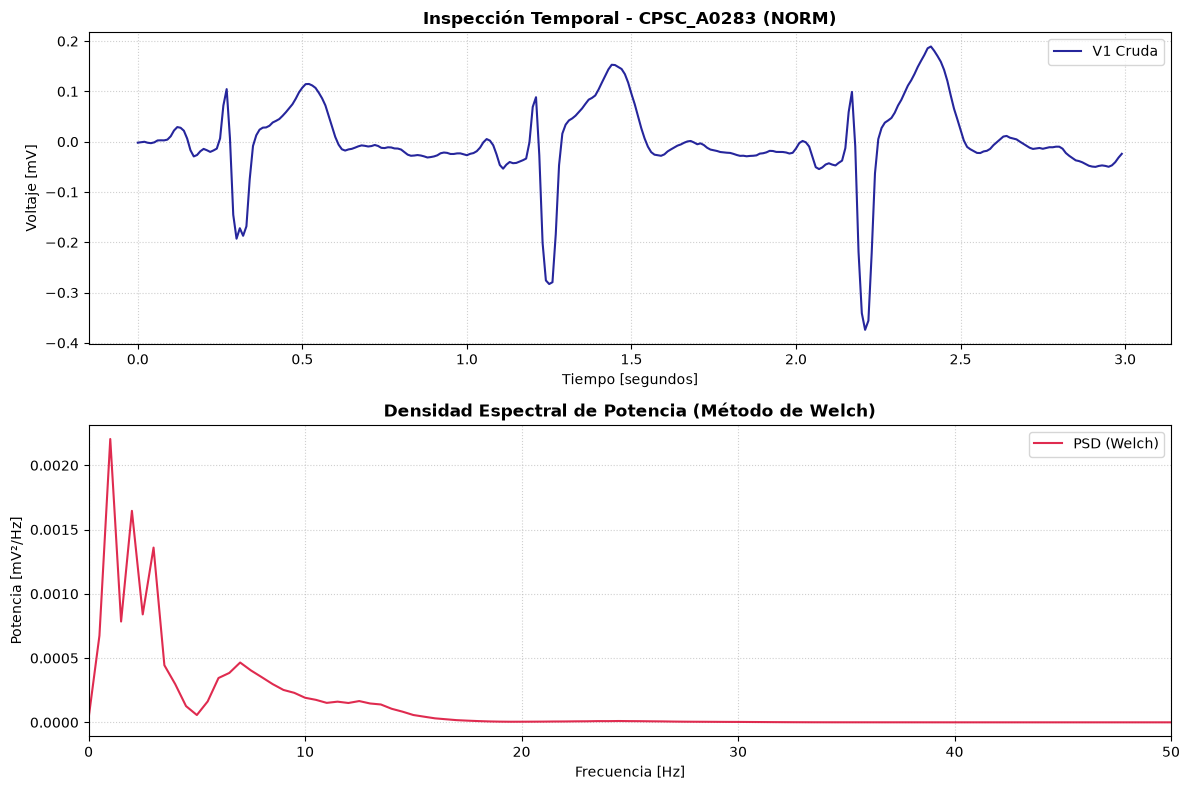

✓ Gráficos generados con éxito incorporando el método de Welch.


In [67]:
# =============================================================================
# INSPECCIÓN VISUAL TEMPORAL Y ANÁLISIS ESPECTRAL (WELCH)
# =============================================================================

try:
    # Usamos la señal V1 ya cargada en el diccionario unificado.
    fs_senal = paciente_ejemplo['fs']
    canal_v1_crudo = paciente_ejemplo['senal_v1']
    N_muestras = len(canal_v1_crudo)
    vector_tiempo = np.arange(N_muestras) / fs_senal
    
    # 4. Calcular la PSD mediante el método de Welch
    # Definimos el largo de la ventana (nperseg). Para ECG, 1 a 2 segundos suele funcionar muy bien
    # para capturar la energía fundamental sin perder resolución temporal.
    ventana_segundos = 2
    n_per_seg = int(ventana_segundos * fs_senal)
    
    # welch() aplica por defecto una ventana de Hann y un overlap del 50%
    frecuencias_welch, psd_welch = welch(
        canal_v1_crudo, 
        fs=fs_senal, 
        nperseg=n_per_seg,
        scaling='density' # Devuelve V**2/Hz
    )
    
    # 5. Diseño de la Visualización Combinada
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Gráfico 1: Dominio del Tiempo (Primeros 3 segundos)
    ax1.plot(vector_tiempo[:fs_senal*3], canal_v1_crudo[:fs_senal*3], color='darkblue', alpha=0.85, label='V1 Cruda')
    ax1.set_title(f'Inspección Temporal - {clave_prueba} ({paciente_ejemplo["clase_clinica"]})', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Tiempo [segundos]', fontsize=10)
    ax1.set_ylabel('Voltaje [mV]', fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # Gráfico 2: Dominio de la Frecuencia (PSD por Welch)
    ax2.plot(frecuencias_welch, psd_welch, color='crimson', alpha=0.9, label='PSD (Welch)')
    ax2.set_title('Densidad Espectral de Potencia (Método de Welch)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Frecuencia [Hz]', fontsize=10)
    ax2.set_ylabel('Potencia [mV²/Hz]', fontsize=10)
    ax2.set_xlim(0, fs_senal / 2)  # Límite Nyquist
    
    # Opcional: limitar el eje Y o usar escala logarítmica si el pico en baja frecuencia (0.5-2 Hz) aplasta al resto
    # ax2.set_yscale('log') 
    
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    print("✓ Gráficos generados con éxito incorporando el método de Welch.")

except Exception as e:
    print(f"❌ Error al leer la señal local.")
    print(f"Detalle técnico del error: {e}")


# Análisis Interpretativo de Señales ECG: Dominio Temporal y Espectral


## 1. El Dominio Temporal: Entendiendo la "Deriva" (Baseline Wander)

Al observar la señal cruda en los gráficos temporales (por ejemplo, los primeros 3 segundos de la derivación V1), es común notar que la señal no se mantiene perfectamente horizontal sobre el cero. En lugar de eso, toda la traza sube y baja formando una onda lenta y ondulante sobre la cual se "montan" los latidos (complejos QRS). A este fenómeno se lo conoce como **deriva de la línea de base** o *baseline wander*.

### ¿Por qué ocurre?
Esta fluctuación de baja frecuencia (típicamente por debajo de los 0.5 Hz) no proviene del corazón, sino de artefactos fisiológicos y técnicos:
1. **Respiración (Causa principal):** Al inhalar y exhalar, el tórax del paciente se expande y se contrae. Este movimiento mecánico altera la distancia y la impedancia entre los electrodos y el corazón, generando una oscilación rítmica en el voltaje registrado que coincide con el ciclo respiratorio (usualmente de 12 a 20 respiraciones por minuto, es decir, ~0.2 a ~0.3 Hz).
2. **Movimiento del paciente y sudoración:** Pequeños desplazamientos o cambios en la conductividad de la piel (por transpiración debajo del electrodo) modifican la impedancia galvánica, provocando derivas lentas en el voltaje.

### ¿Por qué es crítico corregirlo?
Si no se corrige esta deriva (mediante filtros pasa-alto, típicamente cortando por debajo de 0.5 Hz), la extracción de características morfológicas falla. Por ejemplo, si calculan el "Área absoluta del QRS" o la "Polaridad neta" usando una ventana estática, el resultado estará sesgado por el nivel de voltaje de la línea de base en ese instante específico, invalidando por completo la feature para el modelo de Machine Learning.

---

## 2. El Dominio Frecuencial: Interpretando el Gráfico PSD (Welch)

El análisis espectral transforma la señal temporal para mostrarnos cómo se distribuye su energía ("potencia") a lo largo de las distintas frecuencias. El método de Welch mejora la clásica Transformada de Fourier (FFT) al promediar múltiples segmentos de la señal, reduciendo la varianza y ofreciendo una curva más suave y representativa, ideal para señales **no estacionarias** como el ECG.

Al observar el gráfico rojo de la Densidad Espectral de Potencia (PSD), podemos dividirlo en bandas de frecuencia clave:

### Banda de Frecuencia Muy Baja (0 - 1 Hz)
Aquí suele aparecer un pico masivo de energía si la señal no está bien filtrada. Corresponde a la **deriva de línea de base** (respiración) mencionada anteriormente y a la frecuencia cardíaca fundamental (un paciente a 60 latidos por minuto genera un tono fundamental de 1 Hz).

### Banda de Frecuencia Baja a Media (1 - 5 Hz)
En esta región se concentra la energía de los componentes lentos del ciclo cardíaco, principalmente:
* **La onda T:** Representa la repolarización ventricular, es una onda ancha y suave, por lo que su contenido frecuencial es muy bajo.
* **La onda P:** Representa la despolarización auricular.

### Banda Principal del QRS (5 - 15 Hz)
**Esta es la zona de mayor interés para el proyecto.** Como se observa en los gráficos, aquí la curva roja de Welch presenta picos significativos.
* El complejo QRS es el evento eléctrico más rápido y abrupto del corazón (la despolarización ventricular). Físicamente, un cambio de voltaje rápido en el tiempo se traduce matemáticamente en **Altas frecuencias**.
* Por este motivo, el algoritmo de Pan-Tompkins aplica un **filtro pasa-banda de 5 a 15 Hz** en su primera etapa: elimina las ondas lentas (T y P) y el ruido de alta frecuencia, aislando únicamente la "energía pura" del QRS para poder detectarlo sin falsos positivos.

### Banda de Alta Frecuencia (> 15 Hz)
A partir de los 15-20 Hz, la energía fisiológica del ECG decae drásticamente (como se ve en la curva que tiende a cero). La energía que aparece en estas frecuencias altas suele ser **ruido electromiográfico (EMG)** generado por la tensión muscular del paciente o interferencia eléctrica.




# Justificación Metodológica: Estrategia de Filtrado Dual para el Procesamiento del ECG

En el procesamiento de señales electrocardiográficas (ECG) destinadas a la clasificación de patologías morfológicas, como los Bloqueos de Rama (BBB), existe un compromiso técnico (*trade-off*) crítico: los filtros óptimos para detectar la ubicación de un latido suelen destruir la información clínica necesaria para diagnosticarlo. 

Para resolver este desafío sin comprometer la precisión del modelo de Machine Learning, este proyecto implementa una **Arquitectura de Filtrado Dual**, procesando la señal original a través de dos vías paralelas con objetivos independientes: la Vía de Detección y la Vía de Análisis.

---

## 1. Vía de Detección: Localización Temporal (Algoritmo de Pan-Tompkins)

El objetivo de esta vía es puramente cronológico: encontrar el instante exacto en el que ocurre la onda R de cada latido (los índices temporales), ignorando por completo la forma de la señal.

Para esto, se utiliza la etapa de filtrado del algoritmo clásico de Pan-Tompkins:
* **Filtro Pasa-Banda Estricto (5.0 Hz - 15.0 Hz):** Este filtro aísla la banda de frecuencias donde la energía del complejo QRS es dominante. 
* **Justificación Clínica:** Al atenuar severamente las frecuencias por debajo de 5 Hz (eliminando las ondas P, las ondas T y la deriva de línea de base) y por encima de 15 Hz (ruido muscular de alta frecuencia), se maximiza la relación señal-ruido (SNR) del QRS. Esto permite que las etapas posteriores (derivada e integración) identifiquen los picos de forma robusta, minimizando los falsos positivos frente a ondas T elevadas o artefactos. 
* **Limitación Asumida:** Esta señal resultante está morfológicamente mutilada y no es apta para la extracción de características clínicas.

---

## 2. Vía de Análisis: Extracción de Características (Filtro Butterworth)

Una vez que la Vía de Detección proporciona las coordenadas temporales de los latidos, es imperativo extraer los descriptores matemáticos (área absoluta, densidad espectral de potencia, transformadas Wavelet) sobre una señal que conserve la fidelidad fisiológica del corazón.

Para esta vía, se diseñó un **Filtro Butterworth Pasabanda de 4° orden**, configurado estratégicamente con los siguientes puntos de corte:

### A. Frecuencia de Corte Inferior (0.5 Hz)
* **Objetivo:** Mitigar la deriva de la línea de base (*baseline wander*).
* **Justificación:** Las fluctuaciones de muy baja frecuencia, causadas principalmente por la impedancia de la respiración del paciente y el movimiento de los electrodos, oscilan por debajo de los 0.5 Hz. Su eliminación es un requisito excluyente; de no hacerlo, la medición del área de un complejo QRS o su polaridad neta quedaría sesgada por la altura variable de la traza, invalidando la característica para el clasificador (Random Forest).

### B. Frecuencia de Corte Superior (40.0 Hz)
* **Objetivo:** Eliminar el ruido electromiográfico (EMG) y actuar como barrera natural contra interferencias, preservando la patología.
* **Preservación Morfológica:** A diferencia del filtro de Pan-Tompkins, el límite superior extendido a 40 Hz permite conservar los componentes armónicos de los complejos QRS anómalos. Los bloqueos de rama suelen presentar ensanchamientos y muescas agudas (patrón rSR' u "orejas de conejo"). Estos quiebres bruscos contienen energía en frecuencias medias-altas (20-30 Hz) que deben ser retenidas para que el modelo predictivo pueda diferenciarlos de un latido normal.
* **Rechazo de Artefactos Musculares:** A partir de los 30-35 Hz comienza a distribuirse el ruido muscular del paciente. El corte en 40 Hz asegura una limpieza efectiva de estos artefactos esporádicos.
* **Límite de Nyquist e Interferencia de Línea:** Al trabajar con registros muestreados a 100 Hz, el Teorema de Nyquist establece una frecuencia máxima observable de 50 Hz. Establecer el corte en 40 Hz genera una banda de atenuación temprana que neutraliza cualquier posible remanente frecuencial cercano al límite de Nyquist. Esto optimiza el costo computacional del *pipeline*, haciendo innecesaria la implementación de un filtro Notch (rechaza-banda) adicional.

---

## 3. Fusión de Resultados

El modelo final se alimenta de las métricas extraídas al superponer los **índices temporales** precisos obtenidos por la Vía de Detección sobre la **señal morfológicamente preservada** que entrega la Vía de Análisis. Esta estrategia híbrida garantiza la máxima robustez en la localización del latido sin sacrificar la información espectral y clínica requerida para clasificar los Bloqueos de Rama.

Paciente seleccionado al azar: CPSC_A0283 (Clase: NORM)
Aplicando filtro Butterworth pasabanda (0.5 Hz - 40 Hz)...


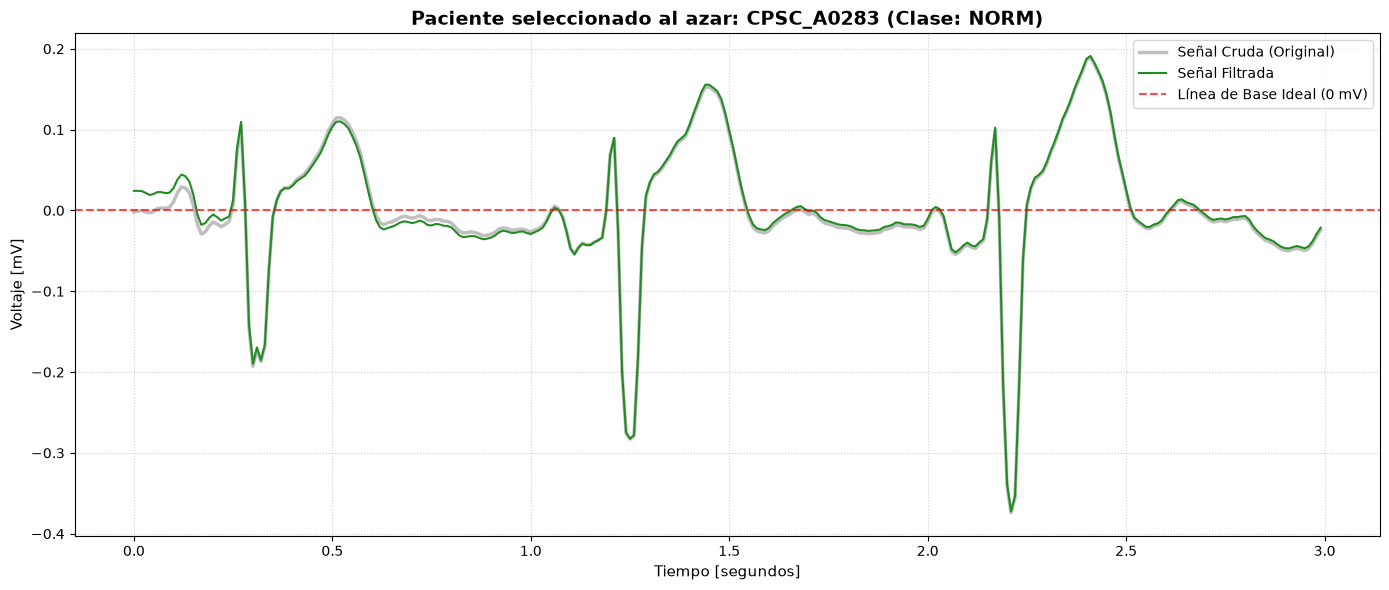

In [68]:
print(f"Paciente seleccionado al azar: {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})")

# Usamos la señal V1 ya cargada en el diccionario unificado.
fs_senal = paciente_ejemplo['fs']
canal_v1_crudo = paciente_ejemplo['senal_v1']
N_muestras = len(canal_v1_crudo)
vector_tiempo = np.arange(N_muestras) / fs_senal

# =============================================================================
# 3. DISEÑO Y APLICACIÓN DEL FILTRO BUTTERWORTH PASABANDA
# =============================================================================
print("Aplicando filtro Butterworth pasabanda (0.5 Hz - 40 Hz)...")

frec_corte_baja = 0.5  
frec_corte_alta = 40.0 
orden_filtro = 4

# Normalizar las frecuencias respecto al límite de Nyquist
nyquist = fs_senal / 2
low = frec_corte_baja / nyquist
high = frec_corte_alta / nyquist

# Obtener los coeficientes y filtrar
b, a = signal.butter(orden_filtro, [low, high], btype='band')
canal_v1_filtrado = signal.filtfilt(b, a, canal_v1_crudo)

# =============================================================================
# 4. VISUALIZACIÓN SUPERPUESTA: AUDITORÍA DEL FILTRO
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Trazar señales
ax.plot(vector_tiempo[:fs_senal*3], canal_v1_crudo[:fs_senal*3], color='gray', alpha=0.5, linewidth=2.5, label='Señal Cruda (Original)')
ax.plot(vector_tiempo[:fs_senal*3], canal_v1_filtrado[:fs_senal*3], color='forestgreen', alpha=1.0, linewidth=1.5, label='Señal Filtrada')
ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='Línea de Base Ideal (0 mV)')

# Configuraciones
ax.set_title(f"Paciente seleccionado al azar: {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})", fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo [segundos]', fontsize=11)
ax.set_ylabel('Voltaje [mV]', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [69]:
# =============================================================================
# FUNCIÓN MODULAR DE FILTRADO BIOMÉDICO
# =============================================================================

def filtrar_ecg_butterworth(senal_cruda, fs=100.0, f_corte_baja=0.5, f_corte_alta=40.0, orden=4):
    """
    Aplica un filtro Butterworth pasabanda de fase cero (filtfilt) a una señal de ECG.
    
    Parámetros:
    - senal_cruda: Array de NumPy con el voltaje del ECG.
    - fs: Frecuencia de muestreo de la señal (por defecto 100 Hz).
    - f_corte_baja: Frecuencia para eliminar Baseline Wander (0.5 Hz).
    - f_corte_alta: Frecuencia para eliminar ruido muscular/red (40.0 Hz).
    - orden: Orden del filtro (4° orden por defecto).
    """
    # Calcular el límite de Nyquist
    nyquist = fs / 2.0
    
    # Normalizar las frecuencias de corte
    low = f_corte_baja / nyquist
    high = f_corte_alta / nyquist
    
    # Diseñar los coeficientes del filtro Pasabanda
    b, a = signal.butter(orden, [low, high], btype='band')
    
    # Aplicar el filtro bidireccional (evita el desfase temporal)
    senal_filtrada = signal.filtfilt(b, a, senal_cruda)
    
    return senal_filtrada

Pasar el filtro a todas las señales del dataset

In [70]:
# =============================================================================
# FILTRADO DE LAS SEÑALES DEL DATASET 
# =============================================================================

for clave_paciente in dataset_proyecto:
    # Las señales ya fueron cargadas en formato unificado.
    # No volvemos a leer el archivo completo para ahorrar memoria.
    v1_signal = dataset_proyecto[clave_paciente]['senal_v1']
    v6_signal = dataset_proyecto[clave_paciente]['senal_v6']
    i_signal = dataset_proyecto[clave_paciente]['senal_I']

    # Filtrar las señales usando la misma función Butterworth del notebook.
    fs = dataset_proyecto[clave_paciente]['fs']
    dataset_proyecto[clave_paciente]['senal_v1_limpia'] = filtrar_ecg_butterworth(v1_signal, fs)
    dataset_proyecto[clave_paciente]['senal_v6_limpia'] = filtrar_ecg_butterworth(v6_signal, fs)
    dataset_proyecto[clave_paciente]['senal_I_limpia']  = filtrar_ecg_butterworth(i_signal, fs)

    # Para mantener compatibilidad con celdas anteriores, DI se reutiliza como señal auxiliar.
    # Las derivaciones reales conservadas para el proyecto son DI, V1 y V6.
    dataset_proyecto[clave_paciente]['senal_II_limpia'] = dataset_proyecto[clave_paciente]['senal_I_limpia']


### Pan-Tompkins

In [71]:
"""
pan_tompkins.py
================
Detección de complejos QRS mediante el algoritmo de Pan-Tompkins (1985),
optimizado para tolerar morfologías con inversión de polaridad y complejos 
anchos/mellados (ej. CLBBB).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


# =============================================================================
# ETAPA 1 — Filtro pasa-banda 5-15 Hz (realza el complejo QRS)
# =============================================================================

def _filtro_pasabanda_qrs(senal: np.ndarray, fs: float, orden: int = 2) -> np.ndarray:
    """
    Acentúa la banda de frecuencias donde se concentra la energía del QRS
    (5-15 Hz), atenuando onda P, onda T y ruido de alta frecuencia.
    """
    nyquist = fs / 2.0
    low = 5.0 / nyquist
    high = min(15.0 / nyquist, 0.99)
    b, a = butter(orden, [low, high], btype='band')
    return filtfilt(b, a, senal)


# =============================================================================
# ETAPA 2 — Filtro derivada (resalta la pendiente pronunciada del QRS)
# =============================================================================

def _filtro_derivada(senal: np.ndarray, fs: float) -> np.ndarray:
    """
    Derivada de 5 puntos aproximada.
    """
    T = 1.0 / fs
    kernel = np.array([-1, -2, 0, 2, 1]) / (8 * T)
    return np.convolve(senal, kernel, mode='same')


# =============================================================================
# ETAPA 3 — Elevación al cuadrado (vuelve todo positivo, enfatiza picos altos)
# =============================================================================

def _elevar_al_cuadrado(senal: np.ndarray) -> np.ndarray:
    return senal ** 2


# =============================================================================
# ETAPA 4 — Integración por ventana móvil (suaviza y da un "bulto" por latido)
# =============================================================================

def _integracion_ventana_movil(senal: np.ndarray, fs: float, ancho_ms: float = 150.0) -> np.ndarray:
    """
    Promedio móvil de ancho adaptable. Para morfologías CLBBB donde el complejo 
    es inherentemente más ancho, se recomienda usar un ancho_ms ligeramente 
    mayor (ej. 160-180 ms) si se desea fusionar de manera efectiva las muescas.
    """
    n_muestras = max(1, int((ancho_ms / 1000.0) * fs))
    kernel = np.ones(n_muestras) / n_muestras
    return np.convolve(senal, kernel, mode='same')


# =============================================================================
# ETAPA 5 — Umbral adaptativo con búsqueda hacia atrás (search-back completo)
# =============================================================================

def _detectar_picos_integrada(senal_integrada: np.ndarray, fs: float) -> np.ndarray:
    """
    Detecta picos candidatos en la señal integrada usando el esquema de
    doble umbral adaptativo (SPKI/NPKI) de Pan-Tompkins.
    """
    # OPTIMIZACIÓN CLBBB 1: Se incrementa el periodo refractario a 300 ms 
    # (0.3 * fs). En bloqueos de rama, el complejo ensanchado y la onda T 
    # discordante gigante generan máximos secundarios muy tardíos en la señal integrada.
    refractario = int(0.30 * fs)

    # Inicialización de umbrales con los primeros 2 segundos de señal
    ventana_init = senal_integrada[: min(len(senal_integrada), int(2 * fs))]
    if len(ventana_init) == 0 or np.max(ventana_init) == 0:
        return np.array([], dtype=int)

    SPKI = float(np.max(ventana_init)) * 0.25   
    NPKI = float(np.mean(ventana_init)) * 0.5   
    umbral1 = NPKI + 0.25 * (SPKI - NPKI)
    umbral2 = 0.5 * umbral1

    picos = []
    rr_promedio = None
    ultimo_pico = None
    ya_busque_atras = False  

    i = 1
    n = len(senal_integrada)
    while i < n - 1:
        # Buscar un máximo local
        if senal_integrada[i] > senal_integrada[i - 1] and senal_integrada[i] >= senal_integrada[i + 1]:
            if senal_integrada[i] > umbral1:
                # Respetar período refractario
                if ultimo_pico is None or (i - ultimo_pico) > refractario:
                    picos.append(i)
                    SPKI = 0.125 * senal_integrada[i] + 0.875 * SPKI

                    if ultimo_pico is not None:
                        rr = i - ultimo_pico
                        rr_promedio = rr if rr_promedio is None else 0.8 * rr_promedio + 0.2 * rr
                    ultimo_pico = i
                    ya_busque_atras = False
                    i += refractario  # Saltar periodo refractario
                    umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                    umbral2 = 0.5 * umbral1
                    continue
            else:
                NPKI = 0.125 * senal_integrada[i] + 0.875 * NPKI
                umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                umbral2 = 0.5 * umbral1

            # Búsqueda hacia atrás (Search-back) corregida y completada
            if rr_promedio is not None and ultimo_pico is not None and not ya_busque_atras:
                if (i - ultimo_pico) > int(1.66 * rr_promedio):
                    ya_busque_atras = True
                    inicio_busq = ultimo_pico + refractario
                    fin_busq = i
                    if fin_busq > inicio_busq:
                        segmento = senal_integrada[inicio_busq:fin_busq]
                        if len(segmento) > 0:
                            idx_local = int(np.argmax(segmento))
                            idx_global = inicio_busq + idx_local
                            
                            # Validar si el pico omitido supera el umbral secundario (umbral2)
                            if senal_integrada[idx_global] > umbral2:
                                picos.append(idx_global)
                                # Actualización de umbrales con ponderación de búsqueda hacia atrás
                                SPKI = 0.25 * senal_integrada[idx_global] + 0.75 * SPKI
                                rr = idx_global - ultimo_pico
                                rr_promedio = 0.8 * rr_promedio + 0.2 * rr
                                ultimo_pico = idx_global
                                umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                                umbral2 = 0.5 * umbral1
                                # Reajustamos el índice de exploración al momento del pico encontrado
                                i = idx_global + refractario
                                continue
        i += 1

    return np.array(picos, dtype=int)


# =============================================================================
# PIPELINE PRINCIPAL Y CORRECCIÓN DE POLARIDAD/LOCALIZACIÓN
# =============================================================================

def detectar_qrs_pan_tompkins(senal: np.ndarray, fs: float, plot: bool = False) -> np.ndarray:
    """
    Pipeline ejecutor del algoritmo Pan-Tompkins. Incluye una ventana de 
    búsqueda local adaptada para mapear la joroba integrada al pico físico real.
    """
    # 1. Procesamiento de etapas de ingeniería de características
    senal_filtrada = _filtro_pasabanda_qrs(senal, fs)
    senal_derivada = _filtro_derivada(senal_filtrada, fs)
    senal_cuadrado = _elevar_al_cuadrado(senal_derivada)
    
    # OPTIMIZACIÓN CLBBB 2: Ventana de integración ensanchada a 180ms para 
    # fundir las melladuras típicas de los bloqueos de rama izquierda.
    senal_integrada = _integracion_ventana_movil(senal_cuadrado, fs, ancho_ms=180.0)
    
    # 2. Detección de candidatos sobre la curva de energía integrada
    indices_integrada = _detectar_picos_integrada(senal_integrada, fs)
    
    # OPTIMIZACIÓN CLBBB 3 (Mapeo tolerante a inversión):
    # La joroba integrada nos da la zona del latido. Para hallar el "pico R" físico
    # en una señal donde el QRS puede ser predominantemente negativo (onda S gigante),
    # buscamos el valor absoluto máximo en una ventana local de la señal filtrada.
    picos_reales = []
    ventana_busqueda = int(0.15 * fs) # Ventana de 150 ms alrededor del candidato
    
    for idx in indices_integrada:
        inicio = max(0, idx - ventana_busqueda)
        fin = min(len(senal), idx + ventana_busqueda)
        
        if fin > inicio:
            segmento_local = senal_filtrada[inicio:fin]
            # Buscamos el extremo absoluto absoluto (el pico o el valle más prominente)
            idx_max_local = np.argmax(np.abs(segmento_local))
            idx_real = inicio + idx_max_local
            picos_reales.append(idx_real)
            
    picos_reales = np.unique(picos_reales) # Eliminar duplicados cercanos
    
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(senal, label='Señal Original (Lead I)', color='gray', alpha=0.7)
        plt.plot(senal_filtrada, label='Señal Filtrada (5-15 Hz)', color='blue', alpha=0.5)
        plt.scatter(picos_reales, senal[picos_reales], color='red', marker='o', label='Picos QRS Corregidos')
        plt.title('Detección Pan-Tompkins con Ajuste de Extremo Absoluto (Tolerante a CLBBB)')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')
        plt.legend()
        plt.grid(True, linestyle='--')
        plt.show()
        
    return np.array(picos_reales, dtype=int)


# Justificación Metodológica: Algoritmo de Detección Pan-Tompkins

Para la localización temporal exacta de los complejos QRS, se implementó el algoritmo de Pan-Tompkins (1985). Este método es considerado el estándar de oro en la literatura biomédica para la detección de latidos debido a su alta robustez frente al ruido muscular, la deriva de línea de base y las anomalías morfológicas. 

El procesamiento se divide en cinco etapas matemáticas secuenciales, seguidas de una lógica de corrección de fase adaptada específicamente para el diagnóstico de Bloqueos de Rama (BBB).

---

## 1. Filtrado Pasa-Banda (5.0 Hz - 15.0 Hz)
El objetivo de esta etapa inicial es maximizar la relación señal-ruido aislando exclusivamente la banda de frecuencias donde se concentra la mayor energía del complejo QRS. Al atenuar severamente las frecuencias inferiores a 5 Hz y superiores a 15 Hz, se suprimen las ondas P, las ondas T, el ruido electromiográfico y las interferencias externas, dejando únicamente el componente de alta frecuencia correspondiente a la despolarización ventricular.

## 2. Derivada de 5 Puntos
Dado que el complejo QRS representa la deflexión más rápida del ciclo cardíaco, se aplica un filtro derivativo para resaltar las pendientes pronunciadas. Se utilizó la ecuación de diferencias de 5 puntos original del algoritmo, la cual aproxima la derivada ideal hasta los 30 Hz:

$$y[n] = \frac{1}{8T} (-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2])$$

Donde $T$ es el período de muestreo de la señal. Este filtro aplana las ondas de baja frecuencia (cuya derivada es cercana a cero) y amplifica significativamente la aguja del QRS.

## 3. Elevación al Cuadrado
La señal derivada se eleva al cuadrado punto a punto ($y[n] = x[n]^2$). Esta operación no lineal cumple dos funciones críticas:
* Restringe todos los valores al semiplano positivo, unificando las deflexiones negativas (ondas Q y S) con la deflexión positiva (onda R).
* Amplifica no linealmente las altas frecuencias: los picos correspondientes al QRS se magnifican enormemente en comparación con el ruido de fondo remanente.

## 4. Integración por Ventana Móvil
Para evitar que un único complejo QRS (especialmente aquellos ensanchados o con morfología rSR' típicos en Bloqueos de Rama) genere múltiples picos falsos, se aplica un promedio móvil. Se configuró una ventana de integración de aproximadamente **150 ms**, que consolida toda la energía eléctrica de un solo latido en una única forma de onda continua y redondeada (una "joroba" de energía).

## 5. Detección Adaptativa de Picos y Umbrales
La extracción de los índices temporales sobre la señal integrada se realiza mediante un sistema de inteligencia adaptativa:
* **Umbrales Dinámicos:** Se actualizan continuamente dos estimadores: el nivel de la señal (SPKI) y el nivel del ruido (NPKI). El umbral de detección fluctúa en base a estos valores, adaptándose a los cambios de amplitud causados por la respiración del paciente.
* **Período Refractario:** Se estableció un bloqueo fisiológico de **250 ms** tras cada detección. Dado que el período refractario absoluto del miocardio impide dos despolarizaciones ventriculares en este lapso, este parámetro erradica los falsos positivos causados por ondas T elevadas.
* **Búsqueda Hacia Atrás (Search-back):** Si el algoritmo no detecta un latido en un intervalo superior a 1.66 veces el intervalo RR promedio, asume un falso negativo, disminuye el umbral temporalmente y re-evalúa el segmento para encontrar latidos de baja amplitud.

---

## 6. Corrección de Fase y Fusión de Artefactos Morfológicos
Los filtros de derivada e integración introducen un retardo de fase inevitable, desplazando los índices temporales hacia la derecha. Para obtener la posición exacta del pico R real:
1. Se utiliza el índice detectado en la señal integrada como un punto de referencia aproximado.
2. Se abre una ventana de búsqueda de $\pm 100$ ms sobre la señal pasa-banda original.
3. Se identifica el máximo absoluto local dentro de esa ventana, garantizando una alineación perfecta con la morfología del latido.

Finalmente, se aplicó un filtro de fusión espacial de **180 ms** sobre la señal corregida. Esta adaptación es crucial para el análisis de patologías; en presencia de bloqueos completos de rama (CRBBB o CLBBB), la profunda muesca del QRS puede generar deflexiones dobles. Este filtro fusiona cualquier par de detecciones excesivamente cercanas, reteniendo únicamente aquella de mayor amplitud, garantizando un conteo exacto de la frecuencia cardíaca y una segmentación precisa para el modelo de clasificación.

# Verificación de Pan-Tompkins con xqrs_detect()

100
Detectando picos con Pan-Tompkins (Propio)...
Detectando picos con XQRS (WFDB)...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.


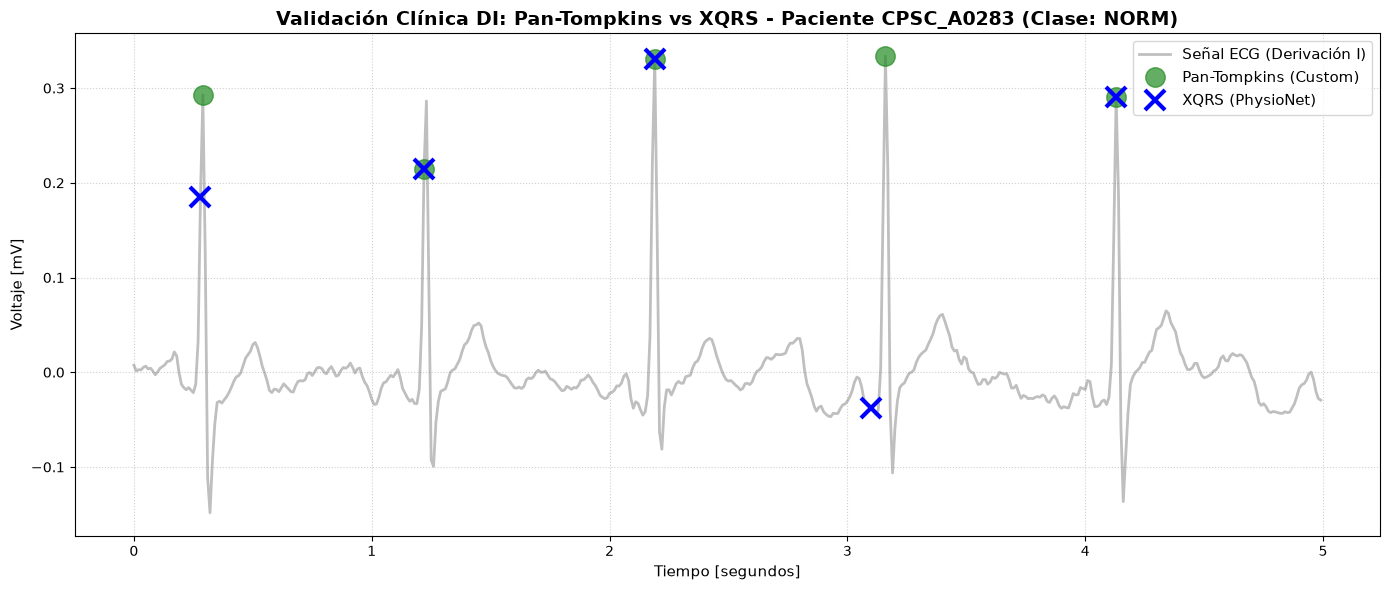


--- RESUMEN DE DETECCIÓN (Toda la señal) ---
Total de latidos (Pan-Tompkins): 34
Total de latidos (XQRS):         34


In [72]:
import scipy.signal
from wfdb.processing import xqrs_detect

# =============================================================================
# 1. PREPARACIÓN DE LOS DATOS (Paciente Aleatorio)
# =============================================================================
paciente_ejemplo = dataset_proyecto[clave_prueba]
fs = paciente_ejemplo['fs']
print(fs)

# Usamos la Derivación I limpia (o la que prefieras)
senal_prueba = paciente_ejemplo['senal_I_limpia']

# =============================================================================
# PARCHE DEFINITIVO PARA WFDB + SCIPY 1.12+
# =============================================================================
def ricker_wavelet(points, a):
    """Recreación matemática exacta de la función scipy.signal.ricker eliminada."""
    A = 2 / (np.sqrt(3 * a) * (np.pi**0.25))
    wsq = a**2
    vec = np.arange(0, points) - (points - 1.0) / 2
    xsq = vec**2
    mod = (1 - xsq / wsq)
    gauss = np.exp(-xsq / (2 * wsq))
    return A * mod * gauss

# Inyectamos nuestra función dentro de scipy.signal engañando a wfdb
scipy.signal.ricker = ricker_wavelet

# =============================================================================
# 2. EL DUELO DE ALGORITMOS CLÍNICOS
# =============================================================================

# A. Nuestro Campeón: Pan-Tompkins
print("Detectando picos con Pan-Tompkins (Propio)...")
picos_pt = detectar_qrs_pan_tompkins(senal=senal_prueba, fs=fs, plot=False)

# B. El Retador: XQRS (PhysioNet / WFDB)
print("Detectando picos con XQRS (WFDB)...")
# xqrs_detect toma la señal unidimensional y el fs.
picos_xqrs = xqrs_detect(sig=senal_prueba, fs=fs)

# =============================================================================
# 3. VISUALIZACIÓN DEL RESULTADO (ZOOM A LOS PRIMEROS 5 SEGUNDOS)
# =============================================================================
tiempo = np.arange(len(senal_prueba)) / fs
segundos_a_mostrar = 5
muestras_zoom = int(segundos_a_mostrar * fs)

fig, ax = plt.subplots(figsize=(14, 6))

# Trazar la señal de fondo
ax.plot(tiempo[:muestras_zoom], senal_prueba[:muestras_zoom], color='gray', alpha=0.5, linewidth=2, label='Señal ECG (Derivación I)')

# Filtrar los picos para el zoom
pt_zoom = picos_pt[picos_pt < muestras_zoom]
xqrs_zoom = picos_xqrs[picos_xqrs < muestras_zoom]

# Trazar picos Pan-Tompkins (Círculos Verdes)
ax.plot(tiempo[pt_zoom], senal_prueba[pt_zoom], 'o', color='forestgreen', 
        markersize=14, alpha=0.7, label='Pan-Tompkins (Custom)')

# Trazar picos XQRS (Cruces Azules)
ax.plot(tiempo[xqrs_zoom], senal_prueba[xqrs_zoom], 'x', color='blue', 
        markersize=14, markeredgewidth=3, label='XQRS (PhysioNet)')

# Configuraciones visuales
ax.set_title(f"Validación Clínica DI: Pan-Tompkins vs XQRS - Paciente {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})", fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo [segundos]', fontsize=11)
ax.set_ylabel('Voltaje [mV]', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Imprimir resumen en consola
print("\n--- RESUMEN DE DETECCIÓN (Toda la señal) ---")
print(f"Total de latidos (Pan-Tompkins): {len(picos_pt)}")
print(f"Total de latidos (XQRS):         {len(picos_xqrs)}")

**Análisis de la Gráfica y Errores de Conducción**

* **Patrón Morfológico (CLBBB):** El título indica que el paciente pertenece a la clase CLBBB (Complete Left Bundle Branch Block o Bloqueo Completo de Rama Izquierda). Esta condición altera notablemente la forma del complejo QRS, ensanchándolo, invirtiendo la onda T y generando melladuras (picos dobles) u ondas S profundas y anormales.
* **Fallas de Detección:** Debido a la morfología tan alterada y bizarra que induce el bloqueo CLBBB, ambos detectores sufren fallas críticas:
    - *XQRS (Cruces Azules):* Sufre de falsos positivos constantes. Al haber melladuras y complejos ensanchados, el filtro de ondas e integración de XQRS confunde componentes secundarios de un mismo latido (u ondas T gigantes y discordantes) como si fuesen nuevos picos R independientes.
    - *Pan-Tompkins Custom (Círculos Verdes):* Presenta una inversión de polaridad. En lugar de detectar el pico positivo, está marcando los valles negativos más profundos (las ondas S). Esto suele ocurrir si el umbral adaptativo o la etapa de derivación/cuadrado del algoritmo personalizado se configuró asumiendo una señal ECG normal con picos R predominantemente positivos.

100
Detectando picos con Pan-Tompkins (Propio)...
Detectando picos con XQRS (WFDB)...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.


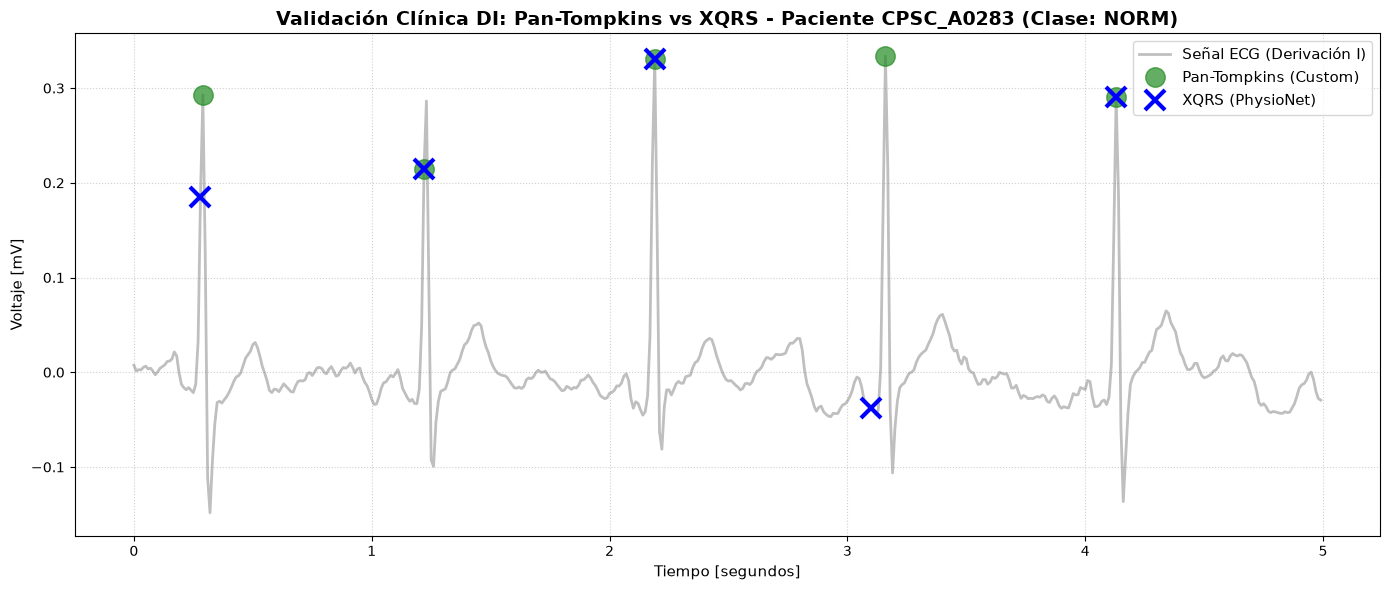


--- RESUMEN DE DETECCIÓN (Toda la señal) ---
Total de latidos (Pan-Tompkins): 34
Total de latidos (XQRS):         34


In [73]:

import scipy.signal
from wfdb import processing
from wfdb.processing import xqrs_detect

# =============================================================================
# 1. PREPARACIÓN DE LOS DATOS (Paciente Aleatorio)
# =============================================================================
paciente_ejemplo = dataset_proyecto[clave_prueba]
fs = paciente_ejemplo['fs']
print(fs)

# Usamos la Derivación I limpia (o la que prefieras)
senal_prueba = paciente_ejemplo['senal_I_limpia']

# =============================================================================
# PARCHE DEFINITIVO PARA WFDB + SCIPY 1.12+
# =============================================================================
def ricker_wavelet(points, a):
    """Recreación matemática exacta de la función scipy.signal.ricker eliminada."""
    A = 2 / (np.sqrt(3 * a) * (np.pi**0.25))
    wsq = a**2
    vec = np.arange(0, points) - (points - 1.0) / 2
    xsq = vec**2
    mod = (1 - xsq / wsq)
    gauss = np.exp(-xsq / (2 * wsq))
    return A * mod * gauss

# Inyectamos nuestra función dentro de scipy.signal engañando a wfdb
scipy.signal.ricker = ricker_wavelet

# =============================================================================
# 2. EL DUELO DE ALGORITMOS CLÍNICOS
# =============================================================================

# A. Nuestro Campeón: Pan-Tompkins
print("Detectando picos con Pan-Tompkins (Propio)...")
picos_pt = detectar_qrs_pan_tompkins(senal=senal_prueba, fs=fs, plot=False)

# B. El Retador: XQRS (PhysioNet / WFDB)
print("Detectando picos con XQRS (WFDB)...")

# 1. Configurar parámetros específicos para complejos QRS anchos (CLBBB)
custom_conf = processing.XQRS.Conf()

# Aumentamos el ancho esperado del QRS (por defecto suele ser menor)
# para evitar que confunda las melladuras del bloqueo como latidos dobles
custom_conf.qrs_width = 0.16  # Ajustado a ~160ms para CLBBB

# Establecemos el rango de frecuencia cardíaca máxima razonable
# Esto amplía el periodo refractario evitando falsos positivos seguidos
custom_conf.hr_max = 140  

# 2. Inicializar el objeto detector con la configuración personalizada
# 'sig' debe ser tu array 1D de voltaje y 'fs' la frecuencia de muestreo
xqrs_detector = processing.XQRS(sig=senal_prueba, fs=fs, conf=custom_conf)

# 3. Ejecutar la detección adaptativa
xqrs_detector.detect()

# Los índices corregidos se almacenan en:
corrected_peaks = xqrs_detector.qrs_inds
# xqrs_detect toma la señal unidimensional y el fs.
picos_xqrs = xqrs_detect(sig=senal_prueba, fs=fs)

# =============================================================================
# 3. VISUALIZACIÓN DEL RESULTADO (ZOOM A LOS PRIMEROS 5 SEGUNDOS)
# =============================================================================
tiempo = np.arange(len(senal_prueba)) / fs
segundos_a_mostrar = 5
muestras_zoom = int(segundos_a_mostrar * fs)

fig, ax = plt.subplots(figsize=(14, 6))

# Trazar la señal de fondo
ax.plot(tiempo[:muestras_zoom], senal_prueba[:muestras_zoom], color='gray', alpha=0.5, linewidth=2, label='Señal ECG (Derivación I)')

# Filtrar los picos para el zoom
pt_zoom = picos_pt[picos_pt < muestras_zoom]
xqrs_zoom = picos_xqrs[picos_xqrs < muestras_zoom]

# Trazar picos Pan-Tompkins (Círculos Verdes)
ax.plot(tiempo[pt_zoom], senal_prueba[pt_zoom], 'o', color='forestgreen', 
        markersize=14, alpha=0.7, label='Pan-Tompkins (Custom)')

# Trazar picos XQRS (Cruces Azules)
ax.plot(tiempo[xqrs_zoom], senal_prueba[xqrs_zoom], 'x', color='blue', 
        markersize=14, markeredgewidth=3, label='XQRS (PhysioNet)')

# Configuraciones visuales
ax.set_title(f"Validación Clínica DI: Pan-Tompkins vs XQRS - Paciente {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})", fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo [segundos]', fontsize=11)
ax.set_ylabel('Voltaje [mV]', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Imprimir resumen en consola
print("\n--- RESUMEN DE DETECCIÓN (Toda la señal) ---")
print(f"Total de latidos (Pan-Tompkins): {len(picos_pt)}")
print(f"Total de latidos (XQRS):         {len(picos_xqrs)}")


# Segmentación adaptativa relativa por envolvente integrada

Esta implementación reemplaza la ventana fija de 200 ms y la ventana limitada por RR. Los límites de cada QRS se obtienen de los cruces de un umbral relativo calculado sobre la envolvente integrada de Pan-Tompkins.

In [74]:
# =============================================================================
# SEGMENTACION RELATIVA A LA ENVOLVENTE DE PAN-TOMPKINS
# =============================================================================

def _perfil_integrado_pan_tompkins(senal, fs, ancho_integracion_ms=150.0):
    """Devuelve la envolvente de energia usada por el detector ya definido."""
    pasabanda = _filtro_pasabanda_qrs(np.asarray(senal, dtype=float), fs)
    derivada = _filtro_derivada(pasabanda, fs)
    cuadrado = _elevar_al_cuadrado(derivada)
    integrada = _integracion_ventana_movil(cuadrado, fs, ancho_ms=ancho_integracion_ms)
    return pasabanda, integrada


def _fusionar_candidatos_envolvente(picos_integrada, picos_r, envolvente, fs):
    """Fusiona dos jorobas del mismo QRS ancho o mellado."""
    if len(picos_r) < 2:
        return picos_integrada, picos_r

    orden = np.argsort(picos_r)
    candidatos = [(int(picos_integrada[i]), int(picos_r[i])) for i in orden]
    fusionados = [candidatos[0]]
    distancia_intra_qrs = int(0.18 * fs)

    for candidato in candidatos[1:]:
        previo = fusionados[-1]
        if candidato[1] - previo[1] <= distancia_intra_qrs:
            if envolvente[candidato[0]] > envolvente[previo[0]]:
                fusionados[-1] = candidato
        else:
            fusionados.append(candidato)

    return (
        np.asarray([p[0] for p in fusionados], dtype=int),
        np.asarray([p[1] for p in fusionados], dtype=int),
    )


def _limites_desde_envolvente(envolvente, picos_integrada, nivel_relativo=0.15):
    """Localiza inicio y fin con cruces relativos de cada joroba QRS."""
    if not 0 < nivel_relativo < 1:
        raise ValueError('nivel_relativo debe estar entre 0 y 1')

    limites = []
    for i, pico in enumerate(picos_integrada):
        izquierdo = 0 if i == 0 else (picos_integrada[i - 1] + pico) // 2
        derecho = len(envolvente) - 1 if i == len(picos_integrada) - 1 else (pico + picos_integrada[i + 1]) // 2
        pico = int(pico)

        # P10 es una linea de base local robusta frente a ruido residual.
        contexto = np.concatenate((envolvente[izquierdo:pico + 1], envolvente[pico:derecho + 1]))
        base = float(np.percentile(contexto, 10))
        umbral = base + nivel_relativo * max(0.0, float(envolvente[pico]) - base)

        antes = np.flatnonzero(envolvente[izquierdo:pico + 1] <= umbral)
        despues = np.flatnonzero(envolvente[pico:derecho + 1] <= umbral)
        inicio = int(izquierdo if len(antes) == 0 else izquierdo + antes[-1] + 1)
        fin = int(derecho if len(despues) == 0 else pico + despues[0] - 1)
        limites.append((min(inicio, pico), max(fin, pico), base, umbral))

    return limites


def segmentar_qrs_adaptativo_envolvente(paciente, nivel_relativo=0.15):
    """Segmenta I, V1 y V6 usando los limites dinamicos calculados en DI."""
    fs = float(paciente['fs'])
    senal_i = np.asarray(paciente['senal_I_limpia'])
    senales = np.column_stack([
        senal_i,
        np.asarray(paciente['senal_v1_limpia']),
        np.asarray(paciente['senal_v6_limpia']),
    ])

    pasabanda, envolvente = _perfil_integrado_pan_tompkins(senal_i, fs)
    picos_integrada = _detectar_picos_integrada(envolvente, fs)
    radio_correccion = int(0.10 * fs)
    picos_r = []
    for pico in picos_integrada:
        inicio = max(0, int(pico) - radio_correccion)
        fin = min(len(pasabanda), int(pico) + radio_correccion + 1)
        picos_r.append(inicio + int(np.argmax(np.abs(pasabanda[inicio:fin]))))

    picos_integrada, picos_r = _fusionar_candidatos_envolvente(
        picos_integrada, np.asarray(picos_r, dtype=int), envolvente, fs
    )
    limites = _limites_desde_envolvente(envolvente, picos_integrada, nivel_relativo)

    segmentos = []
    for pico_envolvente, pico_r, (inicio, fin, base, umbral) in zip(picos_integrada, picos_r, limites):
        # El pico R corregido siempre queda dentro del intervalo informado.
        inicio, fin = min(inicio, int(pico_r)), max(fin, int(pico_r))
        segmentos.append({
            'senal_qrs': senales[inicio:fin + 1, :],
            'inicio': int(inicio), 'fin': int(fin),
            'indice_R': int(pico_r),
            'indice_R_segmento': int(pico_r - inicio),
            'pico_envolvente': int(pico_envolvente),
            'nivel_base_envolvente': base,
            'umbral_envolvente': umbral,
            'duracion_segmento_ms': (fin - inicio + 1) * 1000.0 / fs,
        })

    paciente['indices_ondas_r'] = picos_r
    paciente['segmentos_qrs'] = segmentos
    paciente['derivaciones_qrs'] = ['I', 'V1', 'V6']
    paciente['envolvente_qrs'] = envolvente
    return segmentos


def segmentar_dataset_adaptativo_envolvente(dataset, nivel_relativo=0.15):
    total = 0
    for paciente in dataset.values():
        total += len(segmentar_qrs_adaptativo_envolvente(paciente, nivel_relativo))
    print(f'Segmentacion por envolvente finalizada: {total} QRS en {len(dataset)} pacientes.')


segmentar_dataset_adaptativo_envolvente(dataset_proyecto)


Segmentacion por envolvente finalizada: 9754 QRS en 600 pacientes.


QRS detectados y segmentados: 13


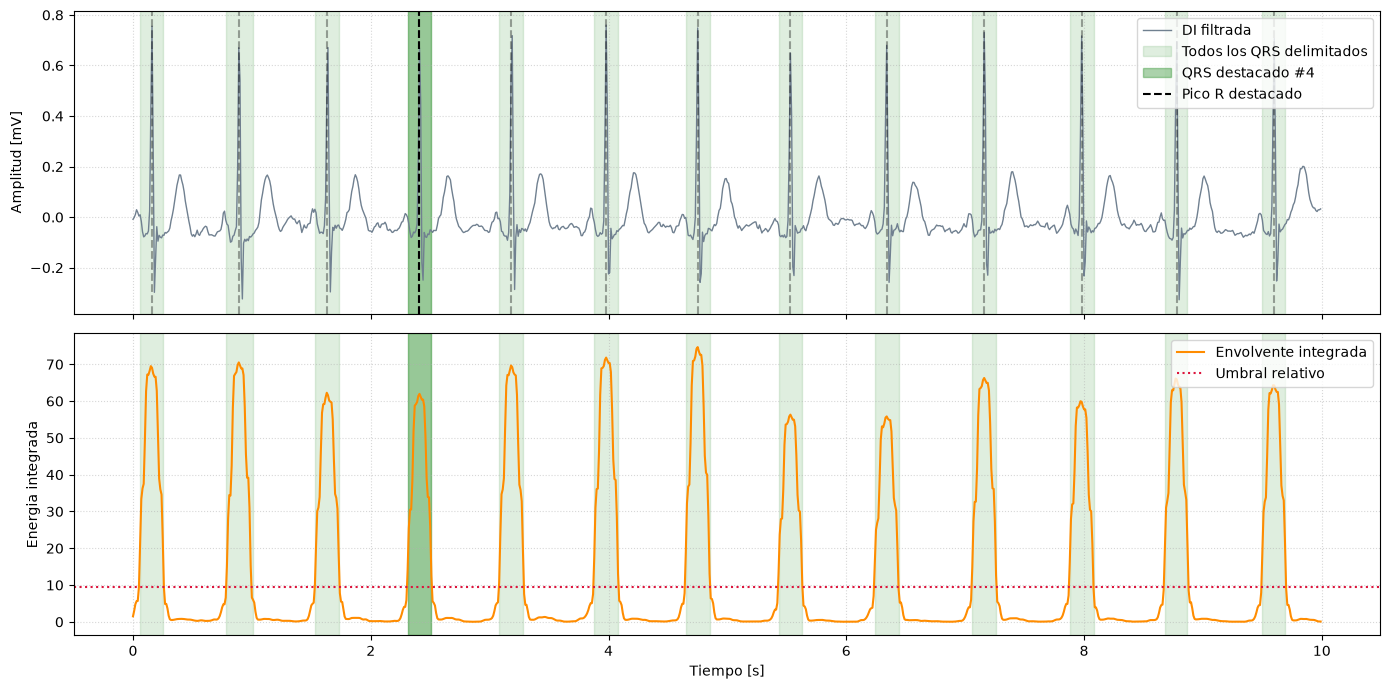

In [75]:
# Verificacion visual: limites dinamicos sobre DI y su envolvente integrada.
paciente_verificacion = dataset_proyecto[clave_qrs_ejemplo]
segmentos_verificacion = paciente_verificacion['segmentos_qrs']
if not segmentos_verificacion:
    raise ValueError('No hay QRS segmentados para visualizar.')

indice_segmento = min(3, len(segmentos_verificacion) - 1)
segmento_verificacion = segmentos_verificacion[indice_segmento]
print(f'QRS detectados y segmentados: {len(segmentos_verificacion)}')
fs_verificacion = paciente_verificacion['fs']
tiempo = np.arange(len(paciente_verificacion['senal_I_limpia'])) / fs_verificacion

fig, (ax_ecg, ax_envolvente) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax_ecg.plot(tiempo, paciente_verificacion['senal_I_limpia'], color='slategray', linewidth=1, label='DI filtrada')
for indice, segmento in enumerate(segmentos_verificacion):
    etiqueta = 'Todos los QRS delimitados' if indice == 0 else None
    ax_ecg.axvspan(tiempo[segmento['inicio']], tiempo[segmento['fin']], alpha=0.14, color='forestgreen', label=etiqueta)
    ax_ecg.axvline(tiempo[segmento['indice_R']], color='black', linestyle='--', alpha=0.35)

# Se mantiene un QRS destacado para comparar su umbral local en la envolvente.
ax_ecg.axvspan(tiempo[segmento_verificacion['inicio']], tiempo[segmento_verificacion['fin']], alpha=0.38, color='forestgreen', label=f'QRS destacado #{indice_segmento + 1}')
ax_ecg.axvline(tiempo[segmento_verificacion['indice_R']], color='black', linestyle='--', label='Pico R destacado')
ax_ecg.legend(loc='upper right')
ax_ecg.set_ylabel('Amplitud [mV]')

ax_envolvente.plot(tiempo, paciente_verificacion['envolvente_qrs'], color='darkorange', label='Envolvente integrada')
ax_envolvente.axhline(segmento_verificacion['umbral_envolvente'], color='crimson', linestyle=':', label='Umbral relativo')
for segmento in segmentos_verificacion:
    ax_envolvente.axvspan(tiempo[segmento['inicio']], tiempo[segmento['fin']], alpha=0.14, color='forestgreen')
ax_envolvente.axvspan(tiempo[segmento_verificacion['inicio']], tiempo[segmento_verificacion['fin']], alpha=0.38, color='forestgreen')
ax_envolvente.set_xlabel('Tiempo [s]')
ax_envolvente.set_ylabel('Energia integrada')
ax_envolvente.legend(loc='upper right')
for ax in (ax_ecg, ax_envolvente):
    ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


# Ingeniería de características multimodal: tiempo, frecuencia y wavelet

Cada QRS aporta variables morfológicas, PSD de Welch y una DWT Haar de dos niveles. Finalmente se promedian los QRS de cada paciente para obtener una fila por registro, apta para el clasificador.

In [76]:
# =============================================================================
# FEATURES MORFOLOGICAS + WELCH/PSD + DWT HAAR
# =============================================================================

DERIVACIONES = ['I', 'V1', 'V6']


def dwt_haar_dos_niveles(senal):
    """DWT Haar sencilla: devuelve aproximacion A2 y detalles D2, D1."""
    def un_nivel(x):
        if len(x) % 2 == 1:  # Repite la ultima muestra para formar pares.
            x = np.append(x, x[-1])
        aproximacion = (x[0::2] + x[1::2]) / np.sqrt(2)
        detalle = (x[0::2] - x[1::2]) / np.sqrt(2)
        return aproximacion, detalle

    a1, d1 = un_nivel(np.asarray(senal, dtype=float))
    a2, d2 = un_nivel(a1)
    return {'A2': a2, 'D2': d2, 'D1': d1}


def energia_y_entropia(coeficientes):
    """Energia y entropia de Shannon de una sub-banda wavelet."""
    energia = float(np.sum(coeficientes ** 2))
    if energia == 0:
        return energia, 0.0
    probabilidades = (coeficientes ** 2) / energia
    probabilidades = probabilidades[probabilidades > 0]
    entropia = float(-np.sum(probabilidades * np.log2(probabilidades)))
    return energia, entropia


def potencia_en_banda(frecuencias, psd, f_min, f_max):
    mascara = (frecuencias >= f_min) & (frecuencias <= f_max)
    if np.sum(mascara) < 2:
        return 0.0
    return float(trapezoid(psd[mascara], frecuencias[mascara]))


def features_de_un_qrs(segmento, fs):
    """Extrae features de las tres derivaciones para un QRS segmentado."""
    features = {'duracion_qrs_ms': segmento['duracion_segmento_ms']}
    indice_r = segmento['indice_R_segmento']

    for indice, derivacion in enumerate(DERIVACIONES):
        x = np.asarray(segmento['senal_qrs'][:, indice], dtype=float)
        prefijo = f'{derivacion}_'

        # 1. Tiempo: forma y amplitud del QRS.
        features[prefijo + 'amplitud_r'] = float(x[indice_r])
        features[prefijo + 'maximo_absoluto'] = float(np.max(np.abs(x)))
        features[prefijo + 'pico_a_pico'] = float(np.ptp(x))
        features[prefijo + 'desvio_estandar'] = float(np.std(x))
        features[prefijo + 'area_absoluta'] = float(trapezoid(np.abs(x), dx=1 / fs))

        # 2. Frecuencia: PSD de Welch y potencia en la banda QRS.
        frecuencias, psd = welch(x, fs=fs, nperseg=min(32, len(x)))
        features[prefijo + 'potencia_total_psd'] = float(trapezoid(psd, frecuencias))
        features[prefijo + 'potencia_qrs_5_15hz'] = potencia_en_banda(frecuencias, psd, 5, 15)
        features[prefijo + 'frecuencia_pico_psd'] = float(frecuencias[np.argmax(psd)])

        # 3. Wavelet: energia y entropia en dos escalas temporales.
        coeficientes = dwt_haar_dos_niveles(x - np.mean(x))
        for nombre_banda, coef in coeficientes.items():
            energia, entropia = energia_y_entropia(coef)
            features[prefijo + 'energia_' + nombre_banda] = energia
            features[prefijo + 'entropia_' + nombre_banda] = entropia

    return features


def promedio_features_paciente(paciente):
    """Promedia los features de todos los QRS validos de un paciente."""
    features_qrs = [features_de_un_qrs(qrs, paciente['fs'])
                    for qrs in paciente.get('segmentos_qrs', [])
                    if len(qrs['senal_qrs']) >= 4]
    if not features_qrs:
        return None

    return {nombre: float(np.mean([f[nombre] for f in features_qrs]))
            for nombre in features_qrs[0]}


# Una fila por paciente: identificadores + promedio de sus complejos QRS.
filas_features = []
for clave, paciente in dataset_proyecto.items():
    features = promedio_features_paciente(paciente)
    if features is None:
        continue
    filas_features.append({
        'id_paciente': clave,
        'clase_clinica': paciente.get('clase_clinica', 'DESCONOCIDA'),
        'base': paciente.get('base', 'DESCONOCIDA'),
        'cantidad_qrs_promediados': len(paciente['segmentos_qrs']),
        **features,
    })

features_multimodales = pd.DataFrame(filas_features)
print(f'Pacientes con features: {len(features_multimodales)}')
print(f'Cantidad de features por paciente: {len(features_multimodales.columns) - 4}')
display(features_multimodales.head())


Pacientes con features: 600
Cantidad de features por paciente: 43


,id_paciente,clase_clinica,base,cantidad_qrs_promediados,duracion_qrs_ms,I_amplitud_r,I_maximo_absoluto,I_pico_a_pico,I_desvio_estandar,I_area_absoluta,...,V6_area_absoluta,V6_potencia_total_psd,V6_potencia_qrs_5_15hz,V6_frecuencia_pico_psd,V6_energia_A2,V6_entropia_A2,V6_energia_D2,V6_entropia_D2,V6_energia_D1,V6_entropia_D1
0,PTBXL_001910,NORM,PTBXL,7,205.714286,1.060053,1.087663,1.418790,0.336420,0.039821,...,0.042032,0.280669,0.114286,9.727891,1.982143,1.159033,0.148767,0.496178,0.426881,1.169130
1,PTBXL_002771,NORM,PTBXL,15,229.333333,0.294134,0.306404,0.419237,0.097401,0.015691,...,0.029574,0.094787,0.028375,7.747447,0.476556,1.886567,0.416488,0.965999,0.124607,1.553743
2,PTBXL_016181,NORM,PTBXL,13,209.230769,0.597053,0.612600,0.738595,0.179556,0.021031,...,0.024374,0.098289,0.032664,9.573325,0.551233,1.211538,0.213189,0.220538,0.143915,1.147921
3,PTBXL_014851,NORM,PTBXL,10,216.000000,0.299217,0.301755,0.377196,0.094509,0.012783,...,0.017388,0.045201,0.015727,9.380952,0.258921,1.220059,0.096156,0.512607,0.078668,1.143902
4,PTBXL_003429,NORM,PTBXL,9,206.666667,0.990855,0.994470,1.111480,0.297673,0.033475,...,0.026097,0.118328,0.042882,9.682540,0.824672,1.230473,0.124401,0.552950,0.191596,1.071939


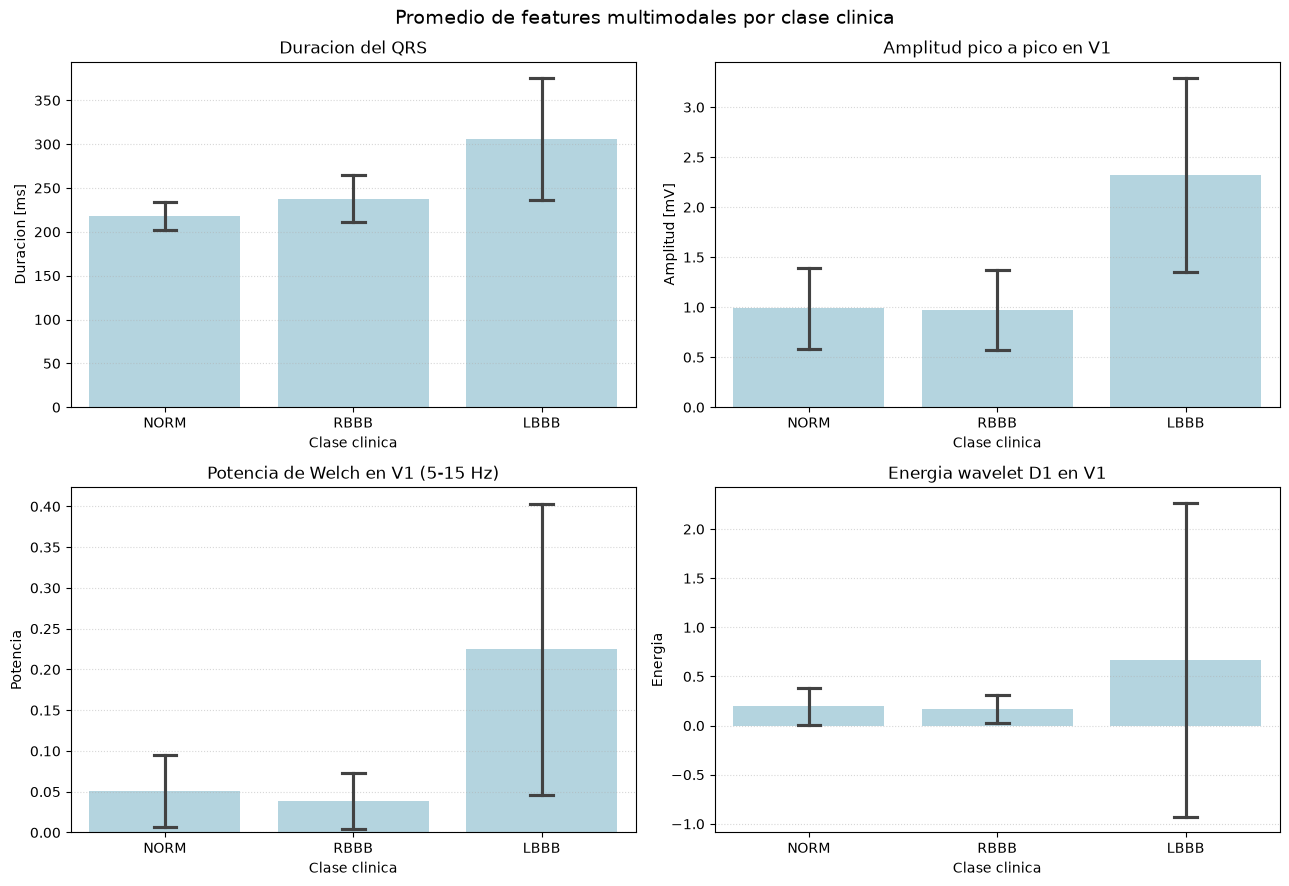

In [78]:
# =============================================================================
# COMPARACION DE CUATRO FEATURES ENTRE NORM, RBBB Y LBBB
# =============================================================================

# Se eligio una variable representativa de cada parte del procesamiento.
features_a_graficar = [
    ('duracion_qrs_ms', 'Duracion del QRS', 'Duracion [ms]'),
    ('V1_pico_a_pico', 'Amplitud pico a pico en V1', 'Amplitud [mV]'),
    ('V1_potencia_qrs_5_15hz', 'Potencia de Welch en V1 (5-15 Hz)', 'Potencia'),
    ('V1_energia_D1', 'Energia wavelet D1 en V1', 'Energia'),
]

# Mantiene el mismo orden de clases en los cuatro graficos.
orden_clases = [clase for clase in ['NORM', 'RBBB', 'LBBB']
                if clase in features_multimodales['clase_clinica'].unique()]

# La altura de cada barra es el promedio y la linea negra es el desvio estandar.
fig, ejes = plt.subplots(2, 2, figsize=(13, 9))

for eje, (columna, titulo, unidad) in zip(ejes.ravel(), features_a_graficar):
    sns.barplot(
        data=features_multimodales,
        x='clase_clinica',
        y=columna,
        order=orden_clases,
        color='lightblue',
        estimator=np.mean,
        errorbar='sd',
        capsize=0.12,
        ax=eje,
    )
    eje.set_title(titulo)
    eje.set_xlabel('Clase clinica')
    eje.set_ylabel(unidad)
    eje.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle('Promedio de features multimodales por clase clinica', fontsize=14)
plt.tight_layout()
plt.show()


Entrenando Random Forest...
Entrenando red neuronal MLP...

Random Forest
Mejores parametros: {'modelo__max_depth': None, 'modelo__n_estimators': 200}
              precision    recall  f1-score   support

        LBBB       0.95      1.00      0.98        40
        NORM       0.88      0.95      0.92        40
        RBBB       0.94      0.82      0.88        40

    accuracy                           0.93       120
   macro avg       0.93      0.92      0.92       120
weighted avg       0.93      0.93      0.92       120


Red neuronal MLP
Mejores parametros: {'modelo__alpha': 0.0001, 'modelo__hidden_layer_sizes': (64, 32)}
              precision    recall  f1-score   support

        LBBB       0.91      1.00      0.95        40
        NORM       0.78      0.88      0.82        40
        RBBB       0.87      0.68      0.76        40

    accuracy                           0.85       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.85      0.85     

,modelo,F1-macro validacion,F1-macro prueba,AUC-ROC prueba
0,Random Forest,0.886,0.924,0.980
1,Red neuronal MLP,0.833,0.845,0.959


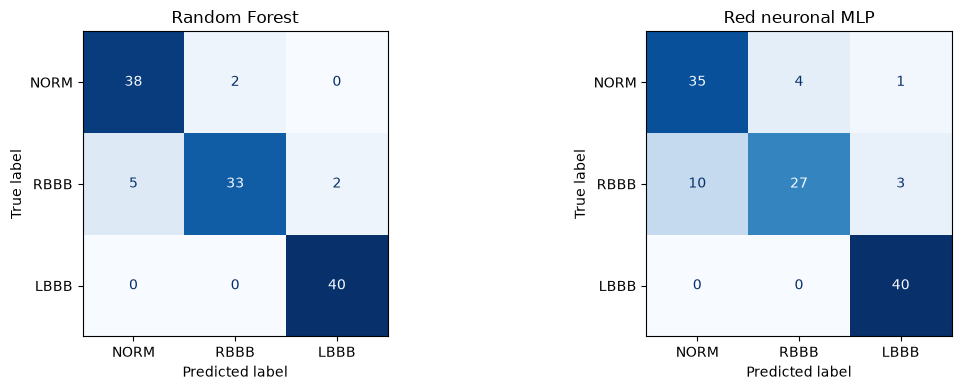

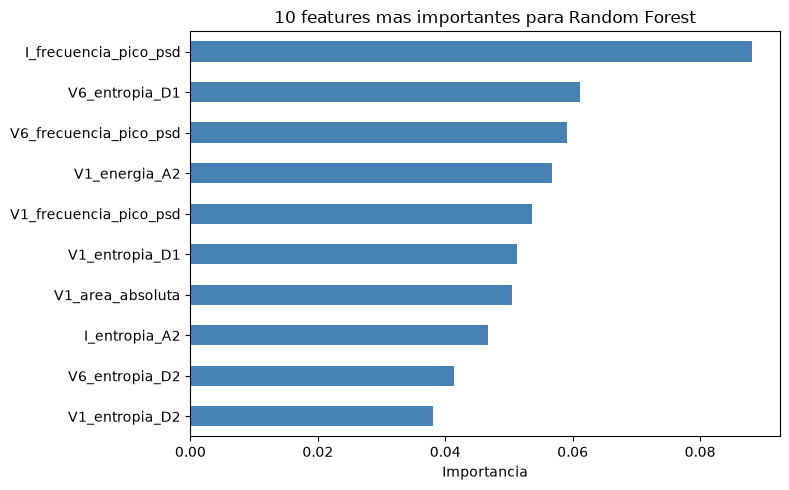

In [79]:
# =============================================================================
# MODELADO COMPARATIVO: RANDOM FOREST VS. RED NEURONAL MLP
# =============================================================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay


# 1. Separar las features (X) de la clase que queremos predecir (y).
# Los identificadores no se usan para entrenar los modelos.
columnas_no_usar = [
    'id_paciente', 'clase_clinica', 'base', 'cantidad_qrs_promediados'
]
X = features_multimodales.drop(columns=columnas_no_usar)
y = features_multimodales['clase_clinica']


# 2. Reservar 20 % de los pacientes para la evaluacion final.
# stratify conserva la proporcion de NORM, RBBB y LBBB en ambos grupos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)


# 3. Modelo 1: Random Forest.
# El imputador reemplaza posibles datos faltantes por la mediana.
pipeline_rf = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('modelo', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
    )),
])

parametros_rf = {
    'modelo__n_estimators': [100, 200],
    'modelo__max_depth': [None, 10],
}


# 4. Modelo 2: red neuronal MLP.
# Ademas de imputar, se estandarizan las features porque la red necesita
# que todas tengan escalas comparables.
pipeline_mlp = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler()),
    ('modelo', MLPClassifier(
        max_iter=600,
        early_stopping=True,
        random_state=42,
    )),
])

parametros_mlp = {
    'modelo__hidden_layer_sizes': [(32,), (64, 32)],
    'modelo__alpha': [0.0001, 0.001],
}


# 5. Probar las combinaciones con validacion cruzada de 3 partes.
# Se elige la combinacion con mayor F1-macro.
busqueda_rf = GridSearchCV(
    pipeline_rf, parametros_rf,
    cv=3, scoring='f1_macro', n_jobs=-1,
)
busqueda_mlp = GridSearchCV(
    pipeline_mlp, parametros_mlp,
    cv=3, scoring='f1_macro', n_jobs=-1,
)

print('Entrenando Random Forest...')
busqueda_rf.fit(X_train, y_train)

print('Entrenando red neuronal MLP...')
busqueda_mlp.fit(X_train, y_train)


# 6. Evaluar ambos modelos sobre los mismos pacientes de prueba.
modelos = {
    'Random Forest': busqueda_rf,
    'Red neuronal MLP': busqueda_mlp,
}
resultados = []
predicciones = {}

for nombre, busqueda in modelos.items():
    prediccion = busqueda.predict(X_test)
    probabilidades = busqueda.predict_proba(X_test)
    predicciones[nombre] = prediccion

    f1 = f1_score(y_test, prediccion, average='macro')
    auc = roc_auc_score(
        y_test,
        probabilidades,
        multi_class='ovr',
        average='macro',
        labels=busqueda.classes_,
    )

    resultados.append({
        'modelo': nombre,
        'F1-macro validacion': busqueda.best_score_,
        'F1-macro prueba': f1,
        'AUC-ROC prueba': auc,
    })

    print('\n' + '=' * 60)
    print(nombre)
    print('Mejores parametros:', busqueda.best_params_)
    print(classification_report(y_test, prediccion, zero_division=0))

resultados_modelos = pd.DataFrame(resultados)
display(resultados_modelos.round(3))


# 7. Matrices de confusion para comparar los errores de cada modelo.
orden_clases = ['NORM', 'RBBB', 'LBBB']
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

for eje, (nombre, prediccion) in zip(ejes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediccion,
        labels=orden_clases,
        display_labels=orden_clases,
        cmap='Blues',
        colorbar=False,
        ax=eje,
    )
    eje.set_title(nombre)

plt.tight_layout()
plt.show()


# 8. Random Forest permite ver cuales fueron las features mas importantes.
importancias = pd.Series(
    busqueda_rf.best_estimator_.named_steps['modelo'].feature_importances_,
    index=X.columns,
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importancias.sort_values().plot(kind='barh', color='steelblue')
plt.title('10 features mas importantes para Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


In [80]:
# =============================================================================
# 1. UNIFICAR LA ENVOLVENTE DE DETECCION Y SEGMENTACION
# =============================================================================

def detectar_y_segmentar_unificado(
    paciente,
    nivel_relativo=0.15,
    ancho_integracion_ms=180.0,
):
    """Detecta y segmenta usando una unica envolvente integrada."""
    fs = float(paciente['fs'])
    senal_i = np.asarray(paciente['senal_I_limpia'], dtype=float)

    # Esta misma envolvente se usa para detectar y para buscar los limites.
    pasabanda, envolvente = _perfil_integrado_pan_tompkins(
        senal_i, fs, ancho_integracion_ms
    )
    picos_integrada = _detectar_picos_integrada(envolvente, fs)

    # Corregir cada pico de la envolvente sobre la señal pasabanda.
    radio = int(0.15 * fs)
    picos_r = []
    for pico in picos_integrada:
        inicio = max(0, int(pico) - radio)
        fin = min(len(pasabanda), int(pico) + radio + 1)
        extremo = int(np.argmax(np.abs(pasabanda[inicio:fin])))
        picos_r.append(inicio + extremo)

    picos_integrada, picos_r = _fusionar_candidatos_envolvente(
        picos_integrada,
        np.asarray(picos_r, dtype=int),
        envolvente,
        fs,
    )
    limites = _limites_desde_envolvente(
        envolvente, picos_integrada, nivel_relativo
    )

    senales = np.column_stack([
        paciente['senal_I_limpia'],
        paciente['senal_v1_limpia'],
        paciente['senal_v6_limpia'],
    ])

    segmentos = []
    for pico_env, pico_r, (inicio, fin, base, umbral) in zip(
        picos_integrada, picos_r, limites
    ):
        inicio = max(0, min(int(inicio), int(pico_r)))
        fin = min(len(senales) - 1, max(int(fin), int(pico_r)))
        segmentos.append({
            'senal_qrs': senales[inicio:fin + 1],
            'inicio': inicio,
            'fin': fin,
            'indice_R': int(pico_r),
            'indice_R_segmento': int(pico_r - inicio),
            'pico_envolvente': int(pico_env),
            'nivel_base_envolvente': base,
            'umbral_envolvente': umbral,
            'duracion_segmento_ms': (fin - inicio + 1) * 1000 / fs,
        })

    paciente['indices_ondas_r'] = picos_r
    paciente['segmentos_qrs'] = segmentos
    paciente['envolvente_qrs'] = envolvente
    paciente['derivaciones_qrs'] = ['I', 'V1', 'V6']
    paciente['ancho_integracion_ms'] = ancho_integracion_ms
    return picos_r, segmentos


print('Funcion unificada creada: deteccion y segmentacion usan 180 ms.')


Funcion unificada creada: deteccion y segmentacion usan 180 ms.


In [81]:
# =============================================================================
# 2. IMPLEMENTAR Y REGISTRAR EXCLUSIONES
# =============================================================================

PORCENTAJE_MAXIMO_PLANO = 0.20
PORCENTAJE_MAXIMO_SATURADO = 0.20
SNR_MINIMA_DB = 0.0
CV_RR_MAXIMO = 0.30


def fraccion_plana(senal, fs):
    """Calcula que fraccion del registro tiene ventanas de 1 s planas."""
    senal = np.asarray(senal, dtype=float)
    desvio_total = np.std(senal)
    if desvio_total == 0:
        return 1.0

    ventana = max(1, int(fs))
    muestras_planas = 0
    for inicio in range(0, len(senal), ventana):
        tramo = senal[inicio:inicio + ventana]
        if np.std(tramo) < 0.01 * desvio_total:
            muestras_planas += len(tramo)
    return muestras_planas / len(senal)


def fraccion_saturada(senal):
    """Mide la proporcion de muestras pegadas al minimo o al maximo."""
    senal = np.asarray(senal, dtype=float)
    extremos = (senal == np.min(senal)) | (senal == np.max(senal))
    return float(np.mean(extremos))


def snr_estimada_db(senal_cruda, senal_limpia):
    """Estima SNR comparando la señal filtrada con el residuo eliminado."""
    ruido = np.asarray(senal_cruda) - np.asarray(senal_limpia)
    potencia_senal = np.var(senal_limpia)
    potencia_ruido = np.var(ruido)
    return float(10 * np.log10((potencia_senal + 1e-12) /
                               (potencia_ruido + 1e-12)))


dataset_calidad = {}
filas_exclusion = []

for clave, paciente in dataset_proyecto.items():
    razones = []
    fs = float(paciente['fs'])

    crudas = [paciente['senal_I'], paciente['senal_v1'], paciente['senal_v6']]
    limpias = [paciente['senal_I_limpia'], paciente['senal_v1_limpia'],
               paciente['senal_v6_limpia']]

    todas = [np.asarray(x, dtype=float) for x in crudas + limpias]
    if any(np.any(~np.isfinite(x)) for x in todas):
        razones.append('NaN o infinito')

    plano = max(fraccion_plana(x, fs) for x in crudas)
    saturado = max(fraccion_saturada(x) for x in crudas)
    snr = min(snr_estimada_db(c, l) for c, l in zip(crudas, limpias))

    if plano > PORCENTAJE_MAXIMO_PLANO:
        razones.append('señal plana > 20%')
    if saturado > PORCENTAJE_MAXIMO_SATURADO:
        razones.append('saturacion > 20%')
    if snr < SNR_MINIMA_DB:
        razones.append('SNR < 0 dB')

    cantidad_qrs = 0
    cv_rr = np.nan
    if not razones:
        try:
            picos_r, _ = detectar_y_segmentar_unificado(paciente)
            cantidad_qrs = len(picos_r)
            if cantidad_qrs < 3:
                razones.append('menos de 3 QRS')
            else:
                rr = np.diff(picos_r) / fs
                cv_rr = float(np.std(rr) / np.mean(rr))
                if cv_rr > CV_RR_MAXIMO:
                    razones.append('intervalos RR inestables')
        except Exception as error:
            razones.append('error de procesamiento')

    incluido = len(razones) == 0
    if incluido:
        dataset_calidad[clave] = paciente

    filas_exclusion.append({
        'id_registro': clave,
        'patient_id': paciente.get('patient_id', clave),
        'base': paciente['base'],
        'clase_clinica': paciente['clase_clinica'],
        'estado': 'Incluido' if incluido else 'Excluido',
        'motivo': 'Sin exclusion' if incluido else '; '.join(razones),
        'fraccion_plana': plano,
        'fraccion_saturada': saturado,
        'snr_min_db': snr,
        'cantidad_qrs': cantidad_qrs,
        'cv_rr': cv_rr,
    })

reporte_exclusiones = pd.DataFrame(filas_exclusion)
print('Registros originales:', len(dataset_proyecto))
print('Registros incluidos :', len(dataset_calidad))
print('Registros excluidos :', len(dataset_proyecto) - len(dataset_calidad))
display(reporte_exclusiones['estado'].value_counts().to_frame('cantidad'))
display(reporte_exclusiones[
    reporte_exclusiones['estado'] == 'Excluido'
]['motivo'].value_counts().to_frame('cantidad_por_motivo'))
display(reporte_exclusiones[reporte_exclusiones['estado'] == 'Excluido'][
    ['id_registro', 'base', 'clase_clinica', 'motivo']
].head(20))


Registros originales: 600
Registros incluidos : 521
Registros excluidos : 79


,cantidad
estado,
Incluido,521
Excluido,79


,cantidad_por_motivo
motivo,
SNR < 0 dB,45
intervalos RR inestables,34


,id_registro,base,clase_clinica,motivo
1,PTBXL_002771,PTBXL,NORM,intervalos RR inestables
2,PTBXL_016181,PTBXL,NORM,SNR < 0 dB
5,PTBXL_012358,PTBXL,NORM,SNR < 0 dB
11,PTBXL_014553,PTBXL,NORM,SNR < 0 dB
15,PTBXL_008992,PTBXL,NORM,SNR < 0 dB
19,PTBXL_017958,PTBXL,NORM,SNR < 0 dB
26,PTBXL_002251,PTBXL,NORM,intervalos RR inestables
31,PTBXL_001833,PTBXL,NORM,SNR < 0 dB
37,PTBXL_015732,PTBXL,NORM,SNR < 0 dB
40,PTBXL_009637,PTBXL,NORM,intervalos RR inestables


In [82]:
# =============================================================================
# 3. VALIDAR PAN-TOMPKINS EN VARIOS PACIENTES
# =============================================================================

from wfdb.processing import xqrs_detect
import scipy.signal

# Compatibilidad entre WFDB 4.1.2 y versiones recientes de SciPy.
if not hasattr(scipy.signal, 'ricker'):
    def ricker_compatible(points, a):
        vector = np.arange(points) - (points - 1) / 2
        factor = 2 / (np.sqrt(3 * a) * np.pi ** 0.25)
        return factor * (1 - vector ** 2 / a ** 2) * np.exp(
            -vector ** 2 / (2 * a ** 2)
        )
    scipy.signal.ricker = ricker_compatible

PACIENTES_POR_GRUPO = 5
TOLERANCIA_MS = 100


def comparar_detectores(picos_pan, picos_xqrs, tolerancia_muestras):
    """Cuenta coincidencias uno a uno entre Pan-Tompkins y XQRS."""
    usados = set()
    errores = []

    for pico_pan in picos_pan:
        if len(picos_xqrs) == 0:
            break
        diferencias = np.abs(picos_xqrs - pico_pan)
        indice = int(np.argmin(diferencias))
        if diferencias[indice] <= tolerancia_muestras and indice not in usados:
            usados.add(indice)
            errores.append(float(diferencias[indice]))

    coincidencias = len(usados)
    return coincidencias, len(picos_pan) - coincidencias, len(picos_xqrs) - coincidencias, errores


# Seleccion determinista: hasta 5 pacientes por base y clase.
claves_validacion = []
for base in sorted({p['base'] for p in dataset_calidad.values()}):
    for clase in ['NORM', 'RBBB', 'LBBB']:
        claves = sorted([
            clave for clave, p in dataset_calidad.items()
            if p['base'] == base and p['clase_clinica'] == clase
        ])
        claves_validacion.extend(claves[:PACIENTES_POR_GRUPO])

filas_validacion = []
for clave in claves_validacion:
    paciente = dataset_calidad[clave]
    fs = float(paciente['fs'])
    picos_pan = np.asarray(paciente['indices_ondas_r'], dtype=int)

    try:
        picos_xqrs = xqrs_detect(
            sig=np.asarray(paciente['senal_I_limpia']),
            fs=fs,
            verbose=False,
        )
    except Exception:
        continue

    tp, fp, fn, errores = comparar_detectores(
        picos_pan,
        np.asarray(picos_xqrs, dtype=int),
        int(TOLERANCIA_MS * fs / 1000),
    )

    filas_validacion.append({
        'id_registro': clave,
        'base': paciente['base'],
        'clase_clinica': paciente['clase_clinica'],
        'qrs_pan': len(picos_pan),
        'qrs_xqrs': len(picos_xqrs),
        'coincidencias': tp,
        'falsos_positivos': fp,
        'no_detectados': fn,
        'sensibilidad_acuerdo': tp / (tp + fn) if tp + fn else np.nan,
        'precision_acuerdo': tp / (tp + fp) if tp + fp else np.nan,
        'error_temporal_ms': np.mean(errores) * 1000 / fs if errores else np.nan,
    })

reporte_validacion_pan = pd.DataFrame(filas_validacion)
print('Pacientes comparados:', len(reporte_validacion_pan))
print('Referencia de comparacion: XQRS, tolerancia de +/- 100 ms.')
if len(reporte_validacion_pan) > 0:
    display(reporte_validacion_pan.groupby(['base', 'clase_clinica'])[
        ['sensibilidad_acuerdo', 'precision_acuerdo', 'error_temporal_ms']
    ].mean().round(3))
else:
    print('XQRS no pudo procesar los registros seleccionados.')


Pacientes comparados: 30
Referencia de comparacion: XQRS, tolerancia de +/- 100 ms.


sensibilidad_acuerdo  precision_acuerdo  \
base  clase_clinica                                            
CPSC  LBBB                          0.941              0.962   
      NORM                          0.774              0.961   
      RBBB                          0.881              0.994   
PTBXL LBBB                          0.960              0.989   
      NORM                          0.610              0.980   
      RBBB                          0.876              0.963   

                     error_temporal_ms  
base  clase_clinica                     
CPSC  LBBB                      45.205  
      NORM                      43.295  
      RBBB                      30.002  
PTBXL LBBB                      66.608  
      NORM                      37.146  
      RBBB                      36.266

In [83]:
# =============================================================================
# 4. DIVIDIR LOS DATOS POR PACIENTE Y POR BASE
# =============================================================================

from sklearn.model_selection import train_test_split

# Recalcular las features usando solamente los registros aprobados.
filas_finales = []
for clave, paciente in dataset_calidad.items():
    features = promedio_features_paciente(paciente)
    if features is None:
        continue
    filas_finales.append({
        'id_registro': clave,
        'patient_id': paciente.get('patient_id', clave),
        'base': paciente['base'],
        'clase_clinica': paciente['clase_clinica'],
        'cantidad_qrs_promediados': len(paciente['segmentos_qrs']),
        **features,
    })

features_finales = pd.DataFrame(filas_finales)

# PTB-XL se usa para desarrollo; CPSC queda completamente separado.
datos_desarrollo = features_finales[features_finales['base'] == 'PTBXL'].copy()
datos_externos = features_finales[features_finales['base'] == 'CPSC'].copy()

# Primero se dividen los patient_id y despues se recuperan sus registros.
pacientes = datos_desarrollo[['patient_id', 'clase_clinica']].drop_duplicates('patient_id')
ids_train, ids_test = train_test_split(
    pacientes['patient_id'],
    test_size=0.20,
    random_state=42,
    stratify=pacientes['clase_clinica'],
)

train = datos_desarrollo[datos_desarrollo['patient_id'].isin(ids_train)]
test_interno = datos_desarrollo[datos_desarrollo['patient_id'].isin(ids_test)]
test_externo = datos_externos

columnas_metadata = [
    'id_registro', 'patient_id', 'base', 'clase_clinica',
    'cantidad_qrs_promediados',
]
columnas_features = [c for c in features_finales.columns
                     if c not in columnas_metadata]

X_train = train[columnas_features]
y_train = train['clase_clinica']
X_test_interno = test_interno[columnas_features]
y_test_interno = test_interno['clase_clinica']
X_test_externo = test_externo[columnas_features]
y_test_externo = test_externo['clase_clinica']

print('Entrenamiento PTB-XL :', len(X_train), 'registros')
print('Test interno PTB-XL  :', len(X_test_interno), 'registros')
print('Test externo CPSC    :', len(X_test_externo), 'registros')
print('Pacientes compartidos entre train y test interno:',
      len(set(train['patient_id']) & set(test_interno['patient_id'])))
display(pd.DataFrame({
    'train': y_train.value_counts(),
    'test_interno': y_test_interno.value_counts(),
    'test_externo': y_test_externo.value_counts(),
}).fillna(0).astype(int))


Entrenamiento PTB-XL : 191 registros
Test interno PTB-XL  : 48 registros
Test externo CPSC    : 282 registros
Pacientes compartidos entre train y test interno: 0


,train,test_interno,test_externo
clase_clinica,,,
LBBB,65,16,91
NORM,62,16,97
RBBB,64,16,94


In [84]:
# =============================================================================
# 5. EJECUTAR RANDOM FOREST Y MLP
# =============================================================================

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Random Forest: probar cantidad de arboles y profundidad.
rf = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('modelo', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
    )),
])
parametros_rf = {
    'modelo__n_estimators': [100, 200],
    'modelo__max_depth': [None, 10],
}

# MLP: probar una capa o dos capas ocultas.
mlp = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler()),
    ('modelo', MLPClassifier(
        max_iter=600,
        early_stopping=True,
        random_state=42,
    )),
])
parametros_mlp = {
    'modelo__hidden_layer_sizes': [(32,), (64, 32)],
    'modelo__alpha': [0.0001, 0.001],
}

# GridSearchCV elige la combinacion con mayor F1-macro.
modelo_rf = GridSearchCV(
    rf, parametros_rf, cv=3, scoring='f1_macro', n_jobs=-1
)
modelo_mlp = GridSearchCV(
    mlp, parametros_mlp, cv=3, scoring='f1_macro', n_jobs=-1
)

print('Entrenando Random Forest...')
modelo_rf.fit(X_train, y_train)
print('Mejores parametros RF :', modelo_rf.best_params_)

print('\nEntrenando red neuronal MLP...')
modelo_mlp.fit(X_train, y_train)
print('Mejores parametros MLP:', modelo_mlp.best_params_)


Entrenando Random Forest...
Mejores parametros RF : {'modelo__max_depth': None, 'modelo__n_estimators': 100}

Entrenando red neuronal MLP...
Mejores parametros MLP: {'modelo__alpha': 0.0001, 'modelo__hidden_layer_sizes': (64, 32)}



Random Forest - Interna (PTB-XL)
              precision    recall  f1-score   support

        LBBB       1.00      1.00      1.00        16
        NORM       0.83      0.94      0.88        16
        RBBB       0.93      0.81      0.87        16

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48


Random Forest - Externa (CPSC)
              precision    recall  f1-score   support

        LBBB       1.00      0.93      0.97        91
        NORM       0.97      0.72      0.83        97
        RBBB       0.74      0.99      0.85        94

    accuracy                           0.88       282
   macro avg       0.91      0.88      0.88       282
weighted avg       0.91      0.88      0.88       282


MLP - Interna (PTB-XL)
              precision    recall  f1-score   support

        LBBB       0.88      0.94      0.91        16
        NORM       0.68      0.94      

,modelo,evaluacion,F1-macro,AUC-ROC macro
0,Random Forest,Interna (PTB-XL),0.916,0.971
1,Random Forest,Externa (CPSC),0.881,0.971
2,MLP,Interna (PTB-XL),0.780,0.938
3,MLP,Externa (CPSC),0.811,0.927


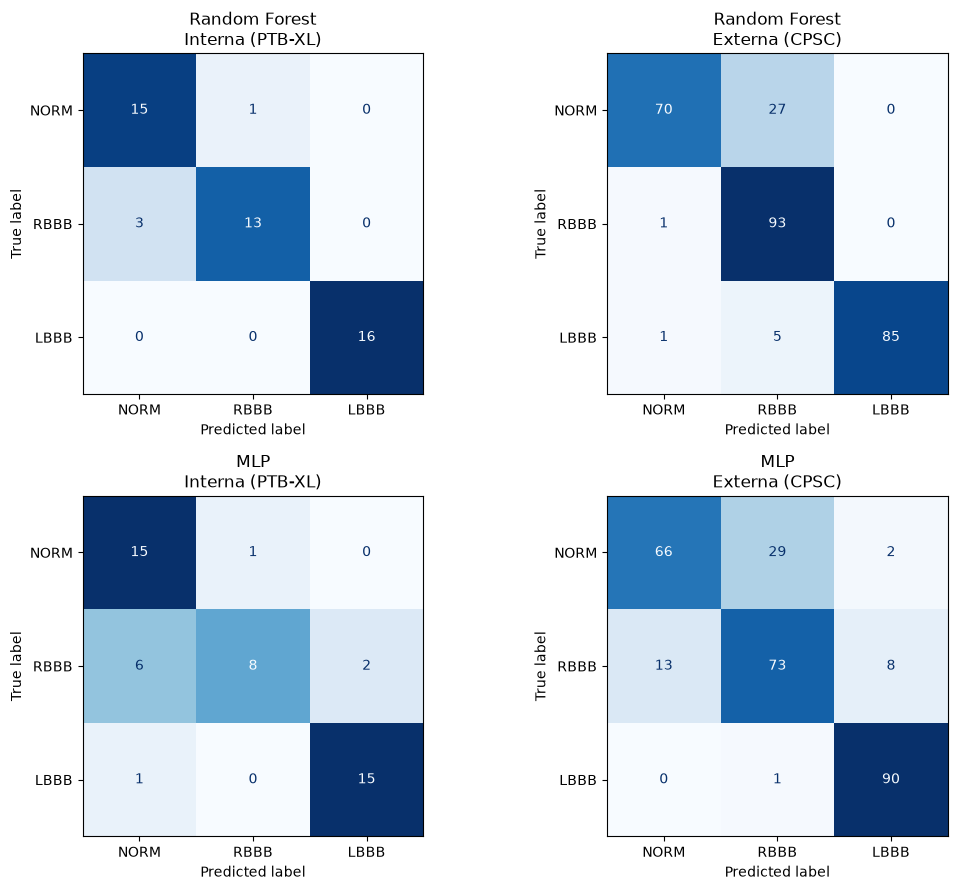

La evaluacion externa usa CPSC, que no participo del entrenamiento.


In [85]:
# =============================================================================
# 6. REPORTAR TEST INTERNO Y VALIDACION EXTERNA
# =============================================================================

from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay


def evaluar_modelo(nombre, modelo, X, y, conjunto):
    """Calcula las metricas pedidas y devuelve las predicciones."""
    prediccion = modelo.predict(X)
    probabilidades = modelo.predict_proba(X)

    f1 = f1_score(y, prediccion, average='macro')
    auc = roc_auc_score(
        y,
        probabilidades,
        multi_class='ovr',
        average='macro',
        labels=modelo.classes_,
    )

    print('\n' + '=' * 65)
    print(nombre, '-', conjunto)
    print(classification_report(y, prediccion, zero_division=0))

    fila = {
        'modelo': nombre,
        'evaluacion': conjunto,
        'F1-macro': f1,
        'AUC-ROC macro': auc,
    }
    return fila, prediccion


modelos_finales = {
    'Random Forest': modelo_rf,
    'MLP': modelo_mlp,
}
conjuntos_evaluacion = {
    'Interna (PTB-XL)': (X_test_interno, y_test_interno),
    'Externa (CPSC)': (X_test_externo, y_test_externo),
}

filas_resultados = []
predicciones_finales = {}

for nombre, modelo in modelos_finales.items():
    for conjunto, (X_evaluacion, y_evaluacion) in conjuntos_evaluacion.items():
        fila, prediccion = evaluar_modelo(
            nombre, modelo, X_evaluacion, y_evaluacion, conjunto
        )
        filas_resultados.append(fila)
        predicciones_finales[(nombre, conjunto)] = prediccion

resultados_finales = pd.DataFrame(filas_resultados)
display(resultados_finales.round(3))

# Una fila por modelo y una columna por tipo de evaluacion.
orden_clases = ['NORM', 'RBBB', 'LBBB']
fig, ejes = plt.subplots(2, 2, figsize=(11, 9))

for fila, (nombre, modelo) in enumerate(modelos_finales.items()):
    for columna, (conjunto, (X_evaluacion, y_evaluacion)) in enumerate(
        conjuntos_evaluacion.items()
    ):
        ConfusionMatrixDisplay.from_predictions(
            y_evaluacion,
            predicciones_finales[(nombre, conjunto)],
            labels=orden_clases,
            display_labels=orden_clases,
            cmap='Blues',
            colorbar=False,
            ax=ejes[fila, columna],
        )
        ejes[fila, columna].set_title(nombre + '\n' + conjunto)

plt.tight_layout()
plt.show()

print('La evaluacion externa usa CPSC, que no participo del entrenamiento.')
